# BPT Comparison And Star-Forming Classification Tests

Use this notebook to iterate on the BPT/star-forming definition. Once the final criteria are chosen, rerun the catalog pipeline and then notebook 8 for paper figures.

In [1]:
from pathlib import Path
import sys

_here = Path.cwd().resolve()
_candidates = (_here, *_here.parents)
REPO_ROOT = next((candidate for candidate in _candidates if (candidate / "m33_pipeline").is_dir()), None)
if REPO_ROOT is None:
    raise RuntimeError(f"Could not locate repo root from {Path.cwd()}")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from m33_pipeline.notebook_setup import prepare_notebook

REPO_ROOT = prepare_notebook(REPO_ROOT)
print(f"Notebook working directory set to: {REPO_ROOT}")

Notebook working directory set to: /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1


In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import astropy.constants as c
import pyneb as pn
import matplotlib.pyplot as plt
HAS_PYNEB=True
from astropy.coordinates import SkyCoord, SkyOffsetFrame
from astropy.visualization import AsinhStretch, PercentileInterval
from skimage.segmentation import find_boundaries
from matplotlib import cm
from skimage.measure import find_contours
from matplotlib.patches import ConnectionPatch
from scipy.optimize import curve_fit
from types import SimpleNamespace
import os
import shutil
import re
import matplotlib as mpl
import seaborn as sns

from m33_pipeline.reporting import (
    add_fit_values,
    add_duplicate_region_values,
    add_halpha_flux_partition_values,
    build_catalog_number_values,
    format_value,
    load_snr_catalog,
    load_wr_catalog,
    write_latex_commands,
)
from m33_pipeline.planetary_nebulae import crossmatch_pne_to_hii_boundaries

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.linewidth": 1.5,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

plt.rcParams["text.usetex"] = False

plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=20)

plt.rc('xtick', direction='in', top=True)
plt.rc('ytick', direction='in', right=True)
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

from m33_pipeline import paths


In [3]:
# Toggle this to also copy selected final figures into PAPER_PLOTS_DRAFT1.
SAVE_FOR_PAPER = True
PAPER_DRAFT_DIR = Path(globals().get('REPO_ROOT', globals().get('ROOT', Path.cwd()))) / 'PAPER_PLOTS_DRAFT1'
PAPER_FIGURE_EXPORTS = {'M33_HII_radial_gradients_multipanel_with_histograms.png': 'M33_radial_gradients_histogram.png', 'M33_allfields_BPT_SNR3_SF_black_gray_compact_objects.png': 'M33_BPT.png', 'M33_HII_Halpha_luminosity_function_correction_comparison_empirical_pdf.png': 'M33_LF_slopes.png', 'M33_HII_L_Ha_sum_dered_vs_areaeq.png': 'M33_L_R.png', 'M33_metallicity_calibrations_paper_multipanel.png': 'M33_metallicity_gradients_selected.png', 'M33_metallicity_vs_logU_pressure_grid.png': 'M33_metallicity_vs_logU_pressure_grid.png', 'M33_metallicity_calibrations_all_indicators_multipanel.png': 'M33_metallicity_calibrations_all_indicators_multipanel.png'}

def save_for_paper(source_path, draft_filename=None):
    if not SAVE_FOR_PAPER:
        return None
    source_path = Path(source_path)
    target_name = draft_filename or PAPER_FIGURE_EXPORTS.get(source_path.name)
    if target_name is None:
        return None
    import shutil
    PAPER_DRAFT_DIR.mkdir(parents=True, exist_ok=True)
    target_path = PAPER_DRAFT_DIR / target_name
    shutil.copyfile(source_path, target_path)
    print(f'Saved paper draft figure: {target_path}')
    return target_path


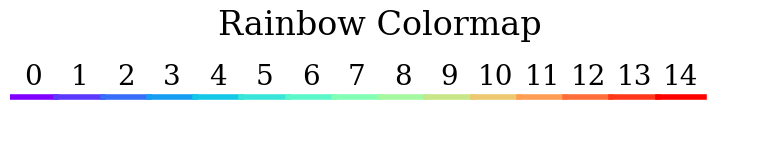

In [4]:
#make a list of 15 evenly spaced colours from the rainbow cmap to be used in all plots
cmap = plt.get_cmap('rainbow')
colors = [cmap(i) for i in np.linspace(0, 1, 15)]
#show the colours
plt.figure(figsize=(8, 2))
for i, color in enumerate(colors):
    plt.plot([i, i + 1], [0, 0], color=color, lw=4)
#label each colour with its index
for i in range(len(colors)):
    plt.text(i + 0.5, 0.1, str(i), ha='center', va='bottom')
plt.xlim(0, len(colors) + 1)
plt.ylim(-1, 1)
plt.axis('off')
plt.title('Rainbow Colormap')
plt.tight_layout()

# Shared plot colors. Non-metallicity catalog-property plots use the green-to-red
# part of rainbow; metallicity plots use a separate blue-purple rainbow slice.
property_cmap = plt.get_cmap('rainbow')
property_color_positions = {
    'sum_A_V': 0.38,
    'L_Ha_sum_dered': 0.52,
    'ne_SII_cm3': 0.66,
    'logU_KK04': 0.76,
    'log_P_thermal_SII_over_k': 0.86,
    'radius_areaeq_pc': 0.94,
}
color_dic = {key: property_cmap(pos) for key, pos in property_color_positions.items()}
lf_comparison_colors = {
    'pre_dig': property_cmap(0.48),
    'dig_corrected': color_dic['L_Ha_sum_dered'],
}



In [5]:
# load in the latest HII region catalog
catalog_method = 'summed_map'  # options: integrated_spectrum, summed_map
catalog_dig_mode = 'dig_subtracted'  # options: dig_subtracted, no_dig
catalog_variant = 'combined'  # options: combined, metallicity, ionization_parameter, density, other_derived, clustering
primary_only = True
field_catalog_pattern = f"flux_catalogs/{catalog_method}/{catalog_dig_mode}/flux_catalog_{{FIELD}}.csv"

plot_root = Path("PAPER_PLOTS") / catalog_method / catalog_dig_mode
plot_root.mkdir(parents=True, exist_ok=True)

def paper_plot_path(filename, subdir=None):
    outdir = plot_root if subdir is None else plot_root / subdir
    outdir.mkdir(parents=True, exist_ok=True)
    return outdir / filename

def resolve_catalog_path(method, dig_mode, variant):
    base_dir = Path("CATALOGS") / "flux_catalogs" / method / dig_mode
    if variant == "combined":
        if hasattr(paths, "combined_catalog_csv"):
            return paths.combined_catalog_csv(method=method, dig_mode=dig_mode)
        return base_dir / "total_flux_catalog_combined.csv"
    if variant == "clustering":
        if hasattr(paths, "derived_catalog_csv"):
            return paths.derived_catalog_csv("clustering", method=method, dig_mode=dig_mode)
        return base_dir / "derived" / "total_flux_catalog_clustering.csv"
    if hasattr(paths, "derived_catalog_csv"):
        return paths.derived_catalog_csv(variant, method=method, dig_mode=dig_mode)
    return base_dir / "derived" / f"total_flux_catalog_{variant}.csv"

def load_catalog_with_field_fallback(method, dig_mode, variant):
    """Load the requested total catalog, or concatenate the available field catalogs."""
    cat_path = resolve_catalog_path(method, dig_mode, variant)
    if cat_path.exists():
        return pd.read_csv(cat_path), str(cat_path)

    base_dir = Path("CATALOGS") / "flux_catalogs" / method / dig_mode
    field_paths = sorted(base_dir.glob("flux_catalog_*.csv"))
    if not field_paths:
        raise FileNotFoundError(
            f"Could not find {cat_path} or any field catalogs in {base_dir}"
        )

    field_catalogs = []
    for field_path in field_paths:
        field_cat = pd.read_csv(field_path)
        if "field" not in field_cat.columns:
            field_cat["field"] = field_path.stem.removeprefix("flux_catalog_")
        field_catalogs.append(field_cat)

    source = f"{len(field_paths)} available field catalog(s) from {base_dir}"
    return pd.concat(field_catalogs, ignore_index=True, sort=False), source

cat, cat_source = load_catalog_with_field_fallback(catalog_method, catalog_dig_mode, catalog_variant)
cat_before_primary_filter = cat.copy()
pn_catalog_path = Path('CATALOGS/planetary_nebulae/M33_PNe_combined_deduplicated.csv')
if pn_catalog_path.exists():
    pn_catalog = pd.read_csv(pn_catalog_path)
    pn_hii_matches, cat = crossmatch_pne_to_hii_boundaries(cat, pn_catalog)
    pn_match_path = Path('CATALOGS/planetary_nebulae/M33_PNe_HII_region_crossmatch.csv')
    pn_match_path.parent.mkdir(parents=True, exist_ok=True)
    pn_hii_matches.to_csv(pn_match_path, index=False)
    pn_derived_path = Path('CATALOGS/flux_catalogs') / catalog_method / catalog_dig_mode / 'derived' / 'total_flux_catalog_pn_crossmatch.csv'
    pn_derived_path.parent.mkdir(parents=True, exist_ok=True)
    cat.to_csv(pn_derived_path, index=False)
    print(f'PN boundary crossmatch: {cat["has_pn_in_boundary"].sum()} HII regions contain at least one PN.')
else:
    pn_catalog = pd.DataFrame()
    print(f'PN catalog not found: {pn_catalog_path}')
if primary_only and 'primary' in cat.columns:
    n_before = len(cat)
    n_non_primary = int((~cat['primary'].fillna(True)).sum())
    cat = cat.loc[cat['primary'].fillna(True)].copy().reset_index(drop=True)
    print(f"Primary-only filtering enabled: removed {n_non_primary} non-primary duplicate rows; {len(cat)} / {n_before} rows kept.")
elif primary_only:
    print("Primary-only filtering requested, but no 'primary' column exists in this catalog.")
print(f"Catalog loaded from {cat_source} with {len(cat.columns)} columns.")
print(f"Plots will be saved under {plot_root}")
for col in cat.columns:
    print(col)


PN boundary crossmatch: 85 HII regions contain at least one PN.
Primary-only filtering enabled: removed 521 non-primary duplicate rows; 5902 / 6423 rows kept.
Catalog loaded from /Users/emmajarvis/Documents/SIGNALS/M33/PAPER1/CATALOGS/flux_catalogs/summed_map/dig_subtracted/total_flux_catalog_combined.csv with 381 columns.
Plots will be saved under PAPER_PLOTS/summed_map/dig_subtracted
region_id
npix_region
npix_dig_annulus
dig_halpha_anchor
dig_halpha_source
F_Halpha_sum_nodig
F_Halpha_e_sum_nodig
SNR_Halpha_sum_nodig
Halpha_dig_median
Halpha_dig_scaled_halpha_median
Halpha_dig_local_median
Halpha_dig_method
Halpha_dig_mad
Halpha_dig_clip_upper
Halpha_dig_npix
Halpha_dig_npix_used
F_Halpha_sum_digsub
F_Hbeta_sum_nodig
F_Hbeta_e_sum_nodig
SNR_Hbeta_sum_nodig
Hbeta_dig_median
Hbeta_dig_scaled_halpha_median
Hbeta_dig_local_median
Hbeta_dig_method
Hbeta_dig_mad
Hbeta_dig_clip_upper
Hbeta_dig_npix
Hbeta_dig_npix_used
F_Hbeta_sum_digsub
F_[OIII]5007_sum_nodig
F_[OIII]5007_e_sum_nodig
SNR_[O

In [6]:
# Star-forming region definition used throughout this notebook.
# Change this one block, then rerun the notebook to switch the selection.
#
# Examples:
#   STAR_FORMING_DEFINITION = {"mode": "bpt"}
#   STAR_FORMING_DEFINITION = {"mode": "sii_ha", "sii_ha_max": 0.4}
#
# For sii_ha mode, sii_ha_max is the linear ratio
# ([SII]6716 + [SII]6731) / Halpha.
STAR_FORMING_DEFINITION = {
    "mode": "bpt",             # options: "bpt", "sii_ha"
    "sii_ha_max": 0.4,      # used only when mode == "sii_ha"
}
STAR_FORMING_SNR_CUT = 3.0


def _first_present_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def _numeric_column(df, candidates):
    col = _first_present_column(df, candidates)
    if col is None:
        return np.full(len(df), np.nan, dtype=float), None
    return pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float), col


def _selected_sii_ha_ratio(df):
    ha, ha_col = _numeric_column(df, [
        "F_Halpha_sum_dered",
        "F_Halpha_sum_digsub",
        "F_Halpha_sum",
        "F_Halpha_sum_nodig",
    ])
    sii6716, sii6716_col = _numeric_column(df, [
        "F_[SII]6716_sum_dered",
        "F_[SII]6716_sum_digsub",
        "F_[SII]6716_sum",
        "F_[SII]6716_sum_nodig",
    ])
    sii6731, sii6731_col = _numeric_column(df, [
        "F_[SII]6731_sum_dered",
        "F_[SII]6731_sum_digsub",
        "F_[SII]6731_sum",
        "F_[SII]6731_sum_nodig",
    ])
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = (sii6716 + sii6731) / ha
    ratio = np.where(np.isfinite(ratio) & (ha > 0) & (sii6716 > 0) & (sii6731 > 0), ratio, np.nan)
    return ratio, {"Halpha": ha_col, "SII6716": sii6716_col, "SII6731": sii6731_col}


def selected_star_forming_mask(df, definition=None):
    definition = dict(STAR_FORMING_DEFINITION if definition is None else definition)
    mode = str(definition.get("mode", "bpt")).strip().lower()
    if mode == "bpt":
        if "BPT_class_sum_dered" not in df.columns:
            return np.zeros(len(df), dtype=bool)
        return df["BPT_class_sum_dered"].astype(str).str.strip().eq("Star-forming").to_numpy(dtype=bool)
    if mode == "sii_ha":
        ratio, _ = _selected_sii_ha_ratio(df)
        max_ratio = float(definition.get("sii_ha_max", 0.4))
        return np.isfinite(ratio) & (ratio < max_ratio)
    raise ValueError(f"Unknown STAR_FORMING_DEFINITION mode: {mode!r}")


def selected_star_forming_snr_mask(df, snr_cut=None, definition=None):
    snr_cut = STAR_FORMING_SNR_CUT if snr_cut is None else snr_cut
    if "all_lines_snr_mask" in globals():
        snr_mask = all_lines_snr_mask(df, snr_cut=snr_cut)
    elif "_all_bpt_lines_snr_mask_for_plotting" in globals():
        snr_mask = _all_bpt_lines_snr_mask_for_plotting(df, snr_cut=snr_cut)
    else:
        snr_cols = [
            "SNR_Halpha_sum",
            "SNR_Hbeta_sum",
            "SNR_[OIII]5007_sum",
            "SNR_[SII]6716_sum",
            "SNR_[NII]6583_sum",
        ]
        snr_mask = np.ones(len(df), dtype=bool)
        for col in snr_cols:
            if col not in df.columns:
                snr_mask &= False
            else:
                snr_mask &= pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float) > snr_cut
    primary = df["primary"].fillna(True).astype(bool).to_numpy() if "primary" in df.columns else np.ones(len(df), dtype=bool)
    return selected_star_forming_mask(df, definition=definition) & snr_mask & primary


def star_forming_definition_label(definition=None):
    definition = dict(STAR_FORMING_DEFINITION if definition is None else definition)
    mode = str(definition.get("mode", "bpt")).strip().lower()
    if mode == "bpt":
        return "BPT star-forming"
    if mode == "sii_ha":
        return rf"[SII]/H$\alpha$ < {float(definition.get('sii_ha_max', 0.4)):.2f}"
    return mode

cat["selected_star_forming"] = selected_star_forming_mask(cat)
cat["selected_star_forming_snr"] = selected_star_forming_snr_mask(cat, snr_cut=STAR_FORMING_SNR_CUT)
print(f"Star-forming definition: {star_forming_definition_label()}")
print(f"Selected star-forming regions: {int(cat['selected_star_forming'].sum())} / {len(cat)}")
print(f"Selected star-forming regions with all-line S/N > {STAR_FORMING_SNR_CUT:g}: {int(cat['selected_star_forming_snr'].sum())} / {len(cat)}")



Star-forming definition: BPT star-forming
Selected star-forming regions: 4498 / 5902
Selected star-forming regions with all-line S/N > 3: 3971 / 5902


In [7]:
# Derived BPT diagnostic columns for testing alternate star-forming definitions.
# The high-OIII population is defined as primary, high-S/N, above the Kauffmann+03 line,
# and not currently BPT-classified as star-forming.
BPT_DIAGNOSTIC_SNR_CUT = 3.0
BPT_DIAGNOSTIC_SNR_LINES = [
    'Halpha',
    'Hbeta',
    '[OIII]5007',
    '[NII]6583',
    '[SII]6716',
    '[SII]6731',
    '[OII]3727',
]


def _diag_first_present_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def _diag_numeric_column(df, candidates):
    col = _diag_first_present_column(df, candidates)
    if col is None:
        return np.full(len(df), np.nan, dtype=float), None
    return pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float), col


def _diag_flux(df, line_name):
    return _diag_numeric_column(df, [
        f'F_{line_name}_sum_dered',
        f'F_{line_name}_sum_digsub',
        f'F_{line_name}_sum',
        f'F_{line_name}_sum_nodig',
    ])


def _diag_snr(df, line_name):
    return _diag_numeric_column(df, [
        f'SNR_{line_name}_sum',
        f'SNR_{line_name}_sum_nodig',
    ])


def _diag_log_ratio(num, den):
    num = np.asarray(num, dtype=float)
    den = np.asarray(den, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        out = np.log10(num / den)
    return np.where(np.isfinite(out) & (num > 0) & (den > 0), out, np.nan)


def _diag_all_line_snr_mask(df, threshold, line_names=BPT_DIAGNOSTIC_SNR_LINES):
    masks = []
    snr_sources = {}
    for line_name in line_names:
        snr_values, snr_col = _diag_snr(df, line_name)
        snr_sources[line_name] = snr_col
        masks.append(np.isfinite(snr_values) & (snr_values > threshold))
    if not masks:
        return np.zeros(len(df), dtype=bool), snr_sources
    return np.logical_and.reduce(masks), snr_sources


def _category_counts(series):
    return series.value_counts(dropna=False).to_dict()


def add_bpt_diagnostic_columns(df, snr_cut=BPT_DIAGNOSTIC_SNR_CUT):
    out = df.copy()
    ha, _ = _diag_flux(out, 'Halpha')
    hb, _ = _diag_flux(out, 'Hbeta')
    oiii, _ = _diag_flux(out, '[OIII]5007')
    oii, _ = _diag_flux(out, '[OII]3727')
    nii, _ = _diag_flux(out, '[NII]6583')
    sii6716, _ = _diag_flux(out, '[SII]6716')
    sii6731, _ = _diag_flux(out, '[SII]6731')
    sii = sii6716 + sii6731

    out['sii_halpha_ratio'] = np.where(np.isfinite(sii / ha) & (sii > 0) & (ha > 0), sii / ha, np.nan)
    out['log_SII_Halpha'] = _diag_log_ratio(sii, ha)
    out['log_NII_Halpha'] = _diag_log_ratio(nii, ha)
    out['log_OIII_OII'] = _diag_log_ratio(oiii, oii)
    out['log_OIII_Halpha'] = _diag_log_ratio(oiii, ha)
    out['log_OIII_Hbeta'] = _diag_log_ratio(oiii, hb)

    with np.errstate(divide='ignore', invalid='ignore'):
        kauffmann_y = 0.61 / (out['log_NII_Halpha'].to_numpy(dtype=float) - 0.05) + 1.3
    x_nii = out['log_NII_Halpha'].to_numpy(dtype=float)
    y_oiii = out['log_OIII_Hbeta'].to_numpy(dtype=float)
    above_kauffmann = np.isfinite(x_nii) & np.isfinite(y_oiii) & ((x_nii >= 0.05) | (y_oiii > kauffmann_y))
    out['above_kauffmann_nii_bpt'] = above_kauffmann

    snr3_all, snr_sources = _diag_all_line_snr_mask(out, snr_cut)
    snr30_all, _ = _diag_all_line_snr_mask(out, 30.0)
    snr50_all, _ = _diag_all_line_snr_mask(out, 50.0)
    out['snr3_all_lines'] = snr3_all
    out['snr30_all_lines'] = snr30_all
    out['snr50_all_lines'] = snr50_all
    out['high_snr_nii_bpt'] = snr3_all

    primary = out['primary'].fillna(True).astype(bool).to_numpy() if 'primary' in out.columns else np.ones(len(out), dtype=bool)
    bpt_sf = out['BPT_class_sum_dered'].astype(str).str.strip().eq('Star-forming').to_numpy() if 'BPT_class_sum_dered' in out.columns else np.zeros(len(out), dtype=bool)
    out['bpt_sf_snr3_all_lines'] = primary & snr3_all & bpt_sf
    out['snr3_non_bpt_sf'] = primary & snr3_all & ~bpt_sf
    out['snr50_non_bpt_sf'] = primary & snr50_all & ~bpt_sf
    out['high_snr_above_kauffmann_non_sf'] = primary & snr3_all & above_kauffmann & ~bpt_sf

    recovered_siiha = primary & snr30_all & ~bpt_sf & np.isfinite(out['sii_halpha_ratio']) & (out['sii_halpha_ratio'] < 0.6)
    out['custom_sf_bpt_or_siiha'] = out['bpt_sf_snr3_all_lines'] | recovered_siiha
    out['custom_sf_recovered_siiha'] = recovered_siiha

    out['class_snr3_only'] = np.where(primary & snr3_all, 'snr3_all_lines', 'low_snr')
    out['class_bpt_snr3_nonbpt'] = np.select(
        [out['bpt_sf_snr3_all_lines'], out['snr3_non_bpt_sf']],
        ['bpt_sf_snr3', 'snr3_non_bpt_sf'],
        default='low_snr',
    )
    out['class_bpt_snr3_nonbpt_snr50'] = np.select(
        [out['bpt_sf_snr3_all_lines'], out['snr50_non_bpt_sf'], out['snr3_non_bpt_sf']],
        ['bpt_sf_snr3', 'snr50_non_bpt_sf', 'snr3_non_bpt_sf'],
        default='low_snr',
    )
    out['class_custom_sf'] = np.select(
        [out['bpt_sf_snr3_all_lines'], out['custom_sf_recovered_siiha'], primary & snr3_all],
        ['bpt_sf_snr3', 'recovered_siiha_sf', 'snr3_non_custom_sf'],
        default='low_snr',
    )

    out.attrs['bpt_diagnostic_snr_sources'] = snr_sources
    return out


cat = add_bpt_diagnostic_columns(cat, snr_cut=BPT_DIAGNOSTIC_SNR_CUT)
print(f"S/N>3 all-line regions: {int(cat['snr3_all_lines'].sum())}")
print(f"BPT SF with S/N>3 all lines: {int(cat['bpt_sf_snr3_all_lines'].sum())}")
print(f"S/N>3 all lines but not BPT SF: {int(cat['snr3_non_bpt_sf'].sum())}")
print(f"S/N>50 all lines and not BPT SF: {int(cat['snr50_non_bpt_sf'].sum())}")
print(f"Recovered SII/Halpha SF candidates: {int(cat['custom_sf_recovered_siiha'].sum())}")
print(f"High-S/N, above-Kauffmann, non-SF regions: {int(cat['high_snr_above_kauffmann_non_sf'].sum())}")
print('S/N columns used:', cat.attrs.get('bpt_diagnostic_snr_sources', {}))



S/N>3 all-line regions: 4417
BPT SF with S/N>3 all lines: 3473
S/N>3 all lines but not BPT SF: 944
S/N>50 all lines and not BPT SF: 65
Recovered SII/Halpha SF candidates: 101
High-S/N, above-Kauffmann, non-SF regions: 941
S/N columns used: {'Halpha': 'SNR_Halpha_sum', 'Hbeta': 'SNR_Hbeta_sum', '[OIII]5007': 'SNR_[OIII]5007_sum', '[NII]6583': 'SNR_[NII]6583_sum', '[SII]6716': 'SNR_[SII]6716_sum', '[SII]6731': 'SNR_[SII]6731_sum', '[OII]3727': 'SNR_[OII]3727_sum'}


In [8]:
# load in the WR and SNR catalogs
wr_catalog = load_wr_catalog()
snr_catalog = load_snr_catalog()


In [9]:

# Functions to plot each map with boundaries colored by BPT class, and WR/SNR locations overlaid.

def field_to_fieldnum(field_label: str) -> str:
    """
    Map your plot field labels to WR catalog Field codes.
    Input examples: 'NE','NW','SE','SW','F5'...'F9'
    Output: 'F1'...'F9'
    """
    mapping = {"NE": "F1", "NW": "F2", "SE": "F3", "SW": "F4"}
    return mapping.get(field_label, field_label)  # F5->F5 etc.


def parse_name_to_coords(name: str) -> SkyCoord:
    # Example: 'J013307.80+302951.1'
    ra_h = name[1:3]
    ra_m = name[3:5]
    ra_s = name[5:10]
    dec_sign = name[10]
    dec_d = name[11:13]
    dec_m = name[13:15]
    dec_s = name[15:]
    ra_str = f"{ra_h}h{ra_m}m{ra_s}s"
    dec_str = f"{dec_sign}{dec_d}d{dec_m}m{dec_s}s"
    return SkyCoord(ra_str, dec_str, frame="icrs")

# ha_fits_path = "M33_Halpha.fits"
def load_halpha_log_and_wcs(wcs: str):
    with fits.open(wcs) as hdul:
        data = hdul[0].data
        hdr = hdul[0].header

    data = np.where(np.isfinite(data), data, np.nan)

    with np.errstate(divide="ignore", invalid="ignore"):
        ha_log = np.log10(data)
    ha_log = np.where(np.isfinite(ha_log), ha_log, np.nan)

    wcs = WCS(hdr)
    return ha_log, wcs


def try_load_boundary_map(field_label: str, boundary_dir="boundary_map"):
    """
    Tries boundary_map/Boundary_map_{FIELD}.fits where FIELD is e.g. NE, NW, SE, SW, F5...
    Returns array or None if missing/unreadable.
    """
    path = os.path.join(boundary_dir, f"Boundary_map_{field_label}.fits")
    if not os.path.exists(path):
        return None
    try:
        return fits.getdata(path)
    except Exception:
        return None


def get_wr_pixels_for_field(wr_catalog: pd.DataFrame, field_num: str, wcs: WCS):
    wr_field = wr_catalog[wr_catalog["Field"] == field_num]
    if len(wr_field) == 0:
        return np.array([]), np.array([])

    coords = [parse_name_to_coords(n) for n in wr_field["Name (star)"]]
    sky = SkyCoord(coords)
    x_wr, y_wr = wcs.world_to_pixel(sky)
    return np.array(x_wr), np.array(y_wr)


def get_snr_pixels_for_field(snr_catalog: pd.DataFrame, wcs: WCS, xlim=(50, 2000), ylim=(50, 2000)):
    """
    Your snr_table.csv loaded with pd.read_csv.
    This assumes columns named exactly 'RA' and 'Dec' OR 'Dec'/'DEC' variants.
    """
    # Be forgiving about Dec column name
    if "Dec" in snr_catalog.columns:
        dec_col = "Dec"
    elif "DEC" in snr_catalog.columns:
        dec_col = "DEC"
    elif "dec" in snr_catalog.columns:
        dec_col = "dec"
    else:
        raise KeyError("SNR catalog must have a Dec/DEC column (plus RA).")

    if "RA" not in snr_catalog.columns:
        raise KeyError("SNR catalog must have an 'RA' column.")

    coords = SkyCoord(snr_catalog["RA"].astype(str),
                      snr_catalog[dec_col].astype(str),
                      unit=(u.hourangle, u.deg))

    x_snr, y_snr = wcs.world_to_pixel(coords)
    x_snr = np.array(x_snr)
    y_snr = np.array(y_snr)

    in_field = (x_snr > xlim[0]) & (x_snr < xlim[1]) & (y_snr > ylim[0]) & (y_snr < ylim[1])
    return x_snr[in_field], y_snr[in_field]


def get_pn_pixels_for_field(pn_catalog: pd.DataFrame, wcs: WCS, xlim=(50, 2000), ylim=(50, 2000)):
    """Return all catalogued PN positions that fall inside the field image limits."""
    if pn_catalog is None or len(pn_catalog) == 0:
        return np.array([]), np.array([])
    if {"RA_deg", "Dec_deg"}.issubset(pn_catalog.columns):
        coords = SkyCoord(
            pn_catalog["RA_deg"].to_numpy(dtype=float) * u.deg,
            pn_catalog["Dec_deg"].to_numpy(dtype=float) * u.deg,
            frame="icrs",
        )
    elif {"RA", "Dec"}.issubset(pn_catalog.columns):
        coords = SkyCoord(pn_catalog["RA"].astype(str), pn_catalog["Dec"].astype(str), unit=(u.hourangle, u.deg))
    else:
        raise KeyError("PN catalog must have RA_deg/Dec_deg or RA/Dec columns.")

    x_pn, y_pn = wcs.world_to_pixel(coords)
    x_pn = np.array(x_pn)
    y_pn = np.array(y_pn)
    in_field = (x_pn > xlim[0]) & (x_pn < xlim[1]) & (y_pn > ylim[0]) & (y_pn < ylim[1])
    return x_pn[in_field], y_pn[in_field]


def _first_existing_path(paths):
    for p in paths:
        if p and os.path.exists(p):
            return p
    return None


def _clean_bpt_class(val):
    if pd.isna(val):
        return "Unclassified"
    val = str(val).strip()
    if val == "" or val.lower() == "nan":
        return "Unclassified"
    return val


def _load_image_and_wcs_separately(image_path, wcs_path=None):
    """
    Load image data from image_path and WCS from wcs_path.
    If wcs_path is None, use the image header for WCS too.
    """
    image_data = np.squeeze(fits.getdata(image_path)).astype(float)

    if wcs_path is None:
        wcs_header = fits.getheader(image_path)
    else:
        wcs_header = fits.getheader(wcs_path)

    wcs = WCS(wcs_header)
    return image_data, wcs


def _safe_log10_image(data):
    """
    Take log10 safely: non-positive values become NaN.
    """
    out = np.full_like(data, np.nan, dtype=float)
    good = np.isfinite(data) & (data > 0)
    out[good] = np.log10(data[good])
    return out


def _finite_sum_mosaic(*arrays):
    """Sum mosaics while preserving pixels that are finite in at least one input."""
    arrays = [np.asarray(arr, dtype=float) for arr in arrays if arr is not None]
    if not arrays:
        return None
    finite_any = np.zeros(arrays[0].shape, dtype=bool)
    summed = np.zeros(arrays[0].shape, dtype=float)
    for arr in arrays:
        finite = np.isfinite(arr)
        finite_any |= finite
        summed += np.where(finite, arr, 0.0)
    summed[~finite_any] = np.nan
    return summed


def _plot_bpt_boundaries_fast(
    ax,
    label_map,
    catalog,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    lw=0.5,
    alpha=0.9,
    zorder=3,
    valid_mask=None,
):
    """
    Faster boundary plotting:
    group region IDs by BPT class, then contour once per class.
    """
    if class_colors is None:
        class_colors = {
            "Star-forming": "blue",
            "Composite": "green",
            "AGN/Shock": "red",
            "Unclassified": "gray",
        }

    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)

    if catalog is None:
        ax.contour(
            (label_int > 0).astype(float),
            levels=[0.5],
            colors="k",
            linewidths=lw,
            alpha=alpha,
            origin="lower",
            zorder=zorder,
        )
        return

    if region_id_col not in catalog.columns:
        raise ValueError(f"'{region_id_col}' not found in catalog columns")
    if bpt_col not in catalog.columns:
        raise ValueError(f"'{bpt_col}' not found in catalog columns")

    cat = catalog.copy()
    cat[region_id_col] = pd.to_numeric(cat[region_id_col], errors="coerce")
    cat = cat.dropna(subset=[region_id_col])
    cat[region_id_col] = cat[region_id_col].astype(int)
    cat[bpt_col] = cat[bpt_col].apply(_clean_bpt_class)

    present_ids = set(np.unique(label_int))

    class_to_region_ids = {}
    for _, row in cat.iterrows():
        rid = row[region_id_col]
        if rid not in present_ids:
            continue
        bpt_class = row[bpt_col]
        class_to_region_ids.setdefault(bpt_class, []).append(rid)

    for bpt_class, region_ids in class_to_region_ids.items():
        if not region_ids:
            continue

        mask = np.isin(label_int, region_ids)
        if not np.any(mask):
            continue

        color = class_colors.get(bpt_class, class_colors["Unclassified"])
        #if BPT class is not star forming, make lw=1.0 and alpha=1.0 for better visibility
        if bpt_class != "Star-forming":
            lw = 1.0
            alpha = 1.0
            
        ax.contour(
            mask.astype(float),
            levels=[0.5],
            colors=[color],
            linewidths=lw,
            alpha=alpha,
            origin="lower",
            zorder=zorder,
        )


def _plot_wr_snr_region_boundaries_fast(
    ax,
    label_map,
    catalog,
    region_id_col='region_id',
    wr_flag_col='has_wr_in_boundary',
    snr_flag_col='has_snr_in_boundary',
    pn_flag_col='has_pn_in_boundary',
    other_color='0.65',
    wr_color='darkviolet',
    snr_color='darkorange',
    both_color='crimson',
    pn_color='royalblue',
    lw=0.45,
    alpha=0.9,
    zorder=3,
):
    """Color region boundaries by whether they contain SNRs or WR stars."""
    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)
    required = {region_id_col, wr_flag_col, snr_flag_col}
    missing = sorted(required.difference(catalog.columns))
    if missing:
        raise KeyError(f'Missing WR/SNR boundary columns: {missing}')

    cat = catalog.copy()
    cat[region_id_col] = pd.to_numeric(cat[region_id_col], errors='coerce')
    cat = cat.dropna(subset=[region_id_col])
    cat[region_id_col] = cat[region_id_col].astype(int)
    wr = cat[wr_flag_col].fillna(False).astype(bool)
    snr = cat[snr_flag_col].fillna(False).astype(bool)
    groups = [
        (~wr & ~snr, other_color, lw, 'Other region'),
        (snr & ~wr, snr_color, 1.6, 'Contains SNR'),
        (wr & ~snr, wr_color, 1.8, 'Contains WR star'),
        (wr & snr, both_color, 2.2, 'Contains SNR and WR star'),
    ]
    for select, color, group_lw, _ in groups:
        region_ids = cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        mask = np.isin(label_int, region_ids)
        if np.any(mask):
            ax.contour(
                mask.astype(float), levels=[0.5], colors=[color],
                linewidths=group_lw, alpha=alpha, origin='lower',
                zorder=zorder + (1 if group_lw > lw else 0),
            )
    if pn_flag_col in cat.columns:
        pn = cat[pn_flag_col].fillna(False).astype(bool)
        pn_region_ids = cat.loc[pn, region_id_col].to_numpy(dtype=int)
        pn_mask = np.isin(label_int, pn_region_ids)
        if np.any(pn_mask):
            ax.contour(
                pn_mask.astype(float), levels=[0.5], colors=[pn_color],
                linewidths=0.6, alpha=1.0, origin='lower', zorder=zorder + 3,
            )


def plot_m33_field_bpt(
    fld,
    ha_dir,
    ha_filename_pattern,
    catalog_dir,
    catalog_pattern,
    boundary_dir,
    boundary_pattern,
    wcs_pattern=None,
    xlim=(50, 2000),
    ylim=(50, 2000),
    savepath=None,
    cmap=cm.get_cmap("rainbow").copy(),
    vmin=-18.5,
    vmax=-15.0,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    boundary_lw=0.4,
    boundary_alpha=0.9,
    field_label_fontsize=20,
    field_label_box_fc="grey",
    field_label_box_alpha=0.8,
    plot_wr=True,
    plot_snr=True,
    plot_pn=False,
    wr_color="lime",
    snr_color="orange",
    pn_color="royalblue",
    figsize=(8, 8),
    show_legend=True,
    boundary_color_mode='bpt',
    wr_region_color='darkviolet',
    snr_region_color='darkorange',
    both_region_color='crimson',
    other_region_color='0.65',
    pn_region_color='royalblue',
    pn_catalog=None,
    combined_catalog=None,
):
    """
    Plot a single field and save it, explicitly using:
      - Ha+OIII file for the image
      - Halpha/WCS file for the WCS
    """
    if class_colors is None:
        class_colors = {
            "Star-forming": "blue",
            "Composite": "green",
            "AGN/Shock": "red",
            "Unclassified": "gray",
        }

    fld_numeric = fld[1:] if fld.startswith("F") else None

    ha_candidates = [
        os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld)),
        os.path.join(ha_dir, ha_filename_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
    ]
    ha_path = _first_existing_path(ha_candidates)
    if ha_path is None:
        raise FileNotFoundError(f"Could not find Ha+OIII map for field {fld}")

    if wcs_pattern is None:
        wcs_path = ha_path
    else:
        wcs_candidates = [
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ]
        wcs_path = _first_existing_path(wcs_candidates)
        if wcs_path is None:
            raise FileNotFoundError(f"Could not find WCS file for field {fld}")

    cat_candidates = [
        os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld)),
        os.path.join(catalog_dir, catalog_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
    ]
    cat_path = _first_existing_path(cat_candidates)
    if cat_path is None:
        raise FileNotFoundError(f"Could not find catalog for field {fld}")

    bnd_candidates = [
        os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld)),
        os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
    ]
    bnd_path = _first_existing_path(bnd_candidates)
    if bnd_path is None:
        raise FileNotFoundError(f"Could not find boundary map for field {fld}")

    # --------------------------------------------------
    # CORRECTED PART:
    # image comes from Ha+OIII file
    # WCS comes from WCS file
    # --------------------------------------------------
    haoiii_data, wcs = _load_image_and_wcs_separately(ha_path, wcs_path)
    ha_log = _safe_log10_image(haoiii_data)

    catalog_processed = pd.read_csv(cat_path)
    if boundary_color_mode == 'wr_snr' and combined_catalog is not None:
        catalog_processed = combined_catalog.loc[combined_catalog['field'] == fld].copy()
    bnd_map = fits.getdata(bnd_path)

    fig, ax = plt.subplots(1, 1, figsize=figsize)

    cmap = cmap.copy()
    cmap.set_bad(color="white")

    im = ax.imshow(
        ha_log,
        origin="lower",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
    )

    if boundary_color_mode == 'wr_snr':
        _plot_wr_snr_region_boundaries_fast(
            ax=ax, label_map=bnd_map, catalog=catalog_processed,
            region_id_col=region_id_col, other_color=other_region_color,
            wr_color=wr_region_color, snr_color=snr_region_color,
            both_color=both_region_color, lw=boundary_lw,
            pn_color=pn_region_color,
            alpha=boundary_alpha, zorder=3,
        )
    else:
        _plot_bpt_boundaries_fast(
            ax=ax,
            label_map=bnd_map,
            catalog=catalog_processed,
            region_id_col=region_id_col,
            bpt_col=bpt_col,
            class_colors=class_colors,
            lw=boundary_lw,
            alpha=boundary_alpha,
            zorder=3,
        )

    if plot_wr:
        field_num = field_to_fieldnum(fld)
        x_wr, y_wr = get_wr_pixels_for_field(wr_catalog, field_num, wcs)
        if x_wr.size:
            ax.scatter(
                x_wr, y_wr,
                marker="*",
                s=50,
                color=wr_color,
                edgecolor="black",
                linewidth=0.8,
                zorder=5,
            )

    if plot_snr:
        x_snr, y_snr = get_snr_pixels_for_field(snr_catalog, wcs, xlim=xlim, ylim=ylim)
        if x_snr.size:
            ax.scatter(
                x_snr, y_snr,
                marker="o",
                s=10,
                facecolors=snr_color,
                edgecolor="black",
                zorder=5,
            )

    if plot_pn:
        x_pn, y_pn = get_pn_pixels_for_field(pn_catalog, wcs, xlim=xlim, ylim=ylim)
        if x_pn.size:
            ax.scatter(
                x_pn, y_pn,
                marker="P",
                s=28,
                facecolors=pn_color,
                edgecolor="black",
                linewidth=0.7,
                zorder=6,
            )

    ax.text(
        0.03, 0.97, fld,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=field_label_fontsize,
        color="k",
        bbox=dict(
            facecolor=field_label_box_fc,
            alpha=field_label_box_alpha,
            edgecolor="none",
            pad=3,
        ),
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_edgecolor("black")

    cbar = fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.05, pad=0.04)
    cbar.set_label(r"$\log_{10}$(H$\alpha$ + [OIII] amplitude)", fontsize=14)

    if show_legend:
        if boundary_color_mode == 'wr_snr':
            legend_handles = [
                plt.Line2D([0], [0], color=other_region_color, lw=2, label='Other region'),
                plt.Line2D([0], [0], color=snr_region_color, lw=2, label='Region contains SNR'),
                plt.Line2D([0], [0], color=wr_region_color, lw=2, label='Region contains WR star'),
                plt.Line2D([0], [0], color=both_region_color, lw=2, label='Region contains both'),
                plt.Line2D([0], [0], color=pn_region_color, lw=2.6, label='Region contains PN'),
            ]
        else:
            legend_handles = [
                plt.Line2D([0], [0], color=class_colors["Star-forming"], lw=2, label="Star-forming"),
                plt.Line2D([0], [0], color=class_colors["Composite"], lw=2, label="Composite"),
                plt.Line2D([0], [0], color=class_colors["AGN/Shock"], lw=2, label="AGN/Shock"),
                plt.Line2D([0], [0], color=class_colors["Unclassified"], lw=2, label="Unclassified"),
            ]

        if plot_wr:
            legend_handles.append(
                plt.Line2D(
                    [0], [0],
                    marker="*",
                    linestyle="None",
                    markerfacecolor=wr_color,
                    markeredgecolor="black",
                    markersize=8,
                    label="WR Stars",
                )
            )

        if plot_snr:
            legend_handles.append(
                plt.Line2D(
                    [0], [0],
                    marker="o",
                    linestyle="None",
                    markerfacecolor=snr_color,
                    markeredgecolor="black",
                    markersize=6,
                    label="SNRs",
                )
            )

        if plot_pn:
            legend_handles.append(
                plt.Line2D(
                    [0], [0],
                    marker="P",
                    linestyle="None",
                    markerfacecolor=pn_color,
                    markeredgecolor="black",
                    markersize=7,
                    label="PNe",
                )
            )

        ax.legend(handles=legend_handles, loc="lower right", frameon=True, fontsize=10)

    if savepath is not None:
        save_dir = os.path.dirname(savepath)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(savepath, dpi=300, facecolor="white", bbox_inches="tight")

    plt.close()


def plot_all_m33_fields_separately(
    field_order,
    output_dir,
    ha_dir,
    ha_filename_pattern,
    catalog_dir,
    catalog_pattern,
    boundary_dir,
    boundary_pattern,
    wcs_pattern=None,
    xlim=(50, 2000),
    ylim=(50, 2000),
    cmap=cm.get_cmap("rainbow").copy(),
    vmin=-18.5,
    vmax=-15.0,
    region_id_col="region_id",
    bpt_col="BPT_class_sum_dered",
    class_colors=None,
    boundary_lw=0.4,
    boundary_alpha=0.9,
    plot_wr=True,
    plot_snr=True,
    plot_pn=False,
    wr_color="lime",
    snr_color="orange",
    pn_color="royalblue",
    figsize=(8, 8),
    filetype="pdf",
    skip_missing=True,
    boundary_color_mode='bpt',
    wr_region_color='darkviolet',
    snr_region_color='darkorange',
    both_region_color='crimson',
    other_region_color='0.65',
    pn_region_color='royalblue',
    filename_suffix='BPT_overlay',
    pn_catalog=None,
    combined_catalog=None,
):
    os.makedirs(output_dir, exist_ok=True)

    plotted_fields = []
    skipped_fields = {}
    for fld in field_order:
        print(f"Plotting {fld}...")
        savepath = os.path.join(output_dir, f"M33_{fld}_{filename_suffix}.{filetype}")

        try:
            plot_m33_field_bpt(
                fld=fld,
                ha_dir=ha_dir,
                ha_filename_pattern=ha_filename_pattern,
                catalog_dir=catalog_dir,
                catalog_pattern=catalog_pattern,
                boundary_dir=boundary_dir,
                boundary_pattern=boundary_pattern,
                wcs_pattern=wcs_pattern,
                xlim=xlim,
                ylim=ylim,
                savepath=savepath,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                region_id_col=region_id_col,
                bpt_col=bpt_col,
                class_colors=class_colors,
                boundary_lw=boundary_lw,
                boundary_alpha=boundary_alpha,
                plot_wr=plot_wr,
                plot_snr=plot_snr,
                plot_pn=plot_pn,
                wr_color=wr_color,
                snr_color=snr_color,
                pn_color=pn_color,
                figsize=figsize,
                show_legend=True,
                boundary_color_mode=boundary_color_mode,
                wr_region_color=wr_region_color,
                snr_region_color=snr_region_color,
                both_region_color=both_region_color,
                other_region_color=other_region_color,
                pn_region_color=pn_region_color,
                pn_catalog=pn_catalog,
                combined_catalog=combined_catalog,
            )
        except FileNotFoundError as exc:
            if not skip_missing:
                raise
            skipped_fields[fld] = str(exc)
            print(f"Skipping {fld}: {exc}")
            continue
        plotted_fields.append(fld)

    print(f"Plotted {len(plotted_fields)} available field(s): {plotted_fields}")
    if skipped_fields:
        print(f"Skipped {len(skipped_fields)} unavailable field(s): {list(skipped_fields)}")
    return plotted_fields, skipped_fields


def _plot_mask_contours_in_mosaic(
    ax,
    mask,
    field_wcs,
    mosaic_wcs,
    color='k',
    lw=0.35,
    alpha=0.85,
    zorder=3,
):
    """Find contours in a field image and plot them in mosaic pixel coordinates."""
    for contour in find_contours(mask.astype(float), 0.5):
        if len(contour) < 3:
            continue
        y_field = contour[:, 0]
        x_field = contour[:, 1]
        sky = field_wcs.pixel_to_world(x_field, y_field)
        x_mosaic, y_mosaic = mosaic_wcs.world_to_pixel(sky)
        good = np.isfinite(x_mosaic) & np.isfinite(y_mosaic)
        if np.sum(good) < 3:
            continue
        ax.plot(
            x_mosaic[good],
            y_mosaic[good],
            color=color,
            lw=lw,
            alpha=alpha,
            zorder=zorder,
        )


def _catalog_field_subset(catalog, field):
    if catalog is None or 'field' not in catalog.columns:
        return pd.DataFrame()
    return catalog.loc[catalog['field'].astype(str) == str(field)].copy()


def _field_valid_pixel_mask(shape, field_valid_bounds=(50, 2000, 50, 2000), field_edge_margin=None):
    ny, nx = shape
    if field_valid_bounds is not None:
        x0, x1, y0, y1 = field_valid_bounds
    else:
        margin = 50 if field_edge_margin is None else field_edge_margin
        x0, x1, y0, y1 = margin, nx - margin, margin, ny - margin
    x0 = max(0, int(np.floor(x0)))
    x1 = min(nx, int(np.ceil(x1)))
    y0 = max(0, int(np.floor(y0)))
    y1 = min(ny, int(np.ceil(y1)))
    mask = np.zeros((ny, nx), dtype=bool)
    if x1 > x0 and y1 > y0:
        mask[y0:y1, x0:x1] = True
    return mask, (x0, x1, y0, y1)


def _add_field_inner_footprint_to_mosaic_mask(mosaic_mask, field_wcs, mosaic_wcs, valid_bounds):
    from skimage.draw import polygon

    x0, x1, y0, y1 = valid_bounds
    corners = np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=float)
    sky_corners = field_wcs.pixel_to_world(corners[:, 0], corners[:, 1])
    xm, ym = mosaic_wcs.world_to_pixel(sky_corners)
    good = np.isfinite(xm) & np.isfinite(ym)
    if np.sum(good) < 3:
        return None
    rr, cc = polygon(ym[good], xm[good], shape=mosaic_mask.shape)
    mosaic_mask[rr, cc] = True
    return (np.nanmin(xm[good]), np.nanmax(xm[good]), np.nanmin(ym[good]), np.nanmax(ym[good]))


def _fill_mosaic_gaps_from_field_maps(
    mosaic_data,
    mosaic_wcs,
    field_order,
    ha_dir,
    wcs_pattern,
    oiii_pattern='M33-{FIELD}/M33{FIELD}-OIII5007flux.fits',
    halpha_only_fields=(),
    field_valid_bounds=None,
    field_edge_margin=0,
):
    filled_total = 0
    halpha_only_set = {str(fld).upper() for fld in halpha_only_fields}
    for fld in field_order:
        fld_numeric = fld[1:] if str(fld).startswith('F') else None
        ha_path = _first_existing_path([
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ])
        if ha_path is None:
            continue
        field_ha = np.squeeze(fits.getdata(ha_path)).astype(float)
        field_wcs = WCS(fits.getheader(ha_path))
        field_data = field_ha
        if str(fld).upper() not in halpha_only_set:
            oiii_path = _first_existing_path([
                os.path.join(ha_dir, oiii_pattern.format(FIELD=fld)),
                os.path.join(ha_dir, oiii_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
            ])
            if oiii_path is not None:
                field_oiii = np.squeeze(fits.getdata(oiii_path)).astype(float)
                field_data = _finite_sum_mosaic(field_ha, field_oiii)

        _, valid_bounds = _field_valid_pixel_mask(
            field_data.shape,
            field_valid_bounds=field_valid_bounds,
            field_edge_margin=field_edge_margin,
        )
        field_footprint = np.zeros(mosaic_data.shape, dtype=bool)
        _add_field_inner_footprint_to_mosaic_mask(field_footprint, field_wcs, mosaic_wcs, valid_bounds)
        missing = field_footprint & (~np.isfinite(mosaic_data) | (mosaic_data <= 0))
        if not np.any(missing):
            continue
        y_mosaic, x_mosaic = np.nonzero(missing)
        sky = mosaic_wcs.pixel_to_world(x_mosaic, y_mosaic)
        x_field, y_field = field_wcs.world_to_pixel(sky)
        xi = np.rint(x_field).astype(int)
        yi = np.rint(y_field).astype(int)
        x0, x1, y0, y1 = valid_bounds
        in_field = (
            np.isfinite(x_field) & np.isfinite(y_field)
            & (xi >= x0) & (xi < x1)
            & (yi >= y0) & (yi < y1)
            & (xi >= 0) & (xi < field_data.shape[1])
            & (yi >= 0) & (yi < field_data.shape[0])
        )
        if not np.any(in_field):
            continue
        values = field_data[yi[in_field], xi[in_field]]
        good_values = np.isfinite(values) & (values > 0)
        if not np.any(good_values):
            continue
        y_fill = y_mosaic[in_field][good_values]
        x_fill = x_mosaic[in_field][good_values]
        mosaic_data[y_fill, x_fill] = values[good_values]
        filled_total += int(np.sum(good_values))
    return filled_total


def _add_field_label_to_mosaic(
    ax,
    field_label,
    field_wcs,
    mosaic_wcs,
    valid_bounds,
    mosaic_shape,
    corner='upper left',
    pad_pixels=70,
    fontsize=11,
    color='white',
):
    import matplotlib.patheffects as path_effects

    x0, x1, y0, y1 = valid_bounds
    x_left = x0 + pad_pixels
    x_right = x1 - pad_pixels
    y_bottom = y0 + pad_pixels
    y_top = y1 - pad_pixels
    corner_key = str(corner).lower().replace('_', ' ')
    x_field = x_right if 'right' in corner_key else x_left
    y_field = y_bottom if 'lower' in corner_key or 'bottom' in corner_key else y_top
    ha = 'right' if 'right' in corner_key else 'left'
    va = 'bottom' if 'lower' in corner_key or 'bottom' in corner_key else 'top'
    sky = field_wcs.pixel_to_world(x_field, y_field)
    x_mosaic, y_mosaic = mosaic_wcs.world_to_pixel(sky)
    if not (np.isfinite(x_mosaic) and np.isfinite(y_mosaic)):
        return None
    if x_mosaic < 0 or x_mosaic >= mosaic_shape[1] or y_mosaic < 0 or y_mosaic >= mosaic_shape[0]:
        return None
    text = ax.text(
        x_mosaic,
        y_mosaic,
        str(field_label),
        color=color,
        fontsize=fontsize,
        fontweight='bold',
        ha=ha,
        va=va,
        zorder=12,
    )
    text.set_path_effects([path_effects.withStroke(linewidth=2.8, foreground='black')])
    return text


def _apply_mosaic_display_mask(im, mosaic_log, valid_mask, percentile_vmin=1, percentile_vmax=99.7):
    display_log = np.where(valid_mask, mosaic_log, np.nan)
    finite = np.isfinite(display_log)
    if np.any(finite):
        im.set_data(display_log)
        im.set_clim(
            np.nanpercentile(display_log[finite], percentile_vmin),
            np.nanpercentile(display_log[finite], percentile_vmax),
        )
    else:
        im.set_data(display_log)
    return display_log


def _format_mosaic_wcs_axes(ax, axis_label_fontsize=10, tick_label_fontsize=8):
    ax.coords[0].set_axislabel('RA (J2000)', fontsize=axis_label_fontsize)
    ax.coords[1].set_axislabel('Dec (J2000)', fontsize=axis_label_fontsize)
    ax.coords[0].set_major_formatter('hh:mm:ss')
    ax.coords[1].set_major_formatter('dd:mm')
    ax.coords[0].set_ticks(spacing=5 * u.arcmin)
    ax.coords[1].set_ticks(spacing=5 * u.arcmin)
    ax.coords[0].set_ticklabel(size=tick_label_fontsize)
    ax.coords[1].set_ticklabel(size=tick_label_fontsize)
    ax.coords[0].display_minor_ticks(True)
    ax.coords[1].display_minor_ticks(True)


def _add_full_width_mosaic_colorbar(fig, ax, im, label, label_fontsize=10, tick_labelsize=8):
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes

    cax = inset_axes(
        ax, width='100%', height='2.5%', loc='lower center',
        bbox_to_anchor=(0, -0.085, 1, 1), bbox_transform=ax.transAxes,
        borderpad=0,
    )
    cbar = fig.colorbar(im, cax=cax, orientation='horizontal')
    cbar.set_label(label, fontsize=label_fontsize)
    cbar.ax.tick_params(labelsize=tick_labelsize)
    return cbar


def _plot_bpt_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    region_id_col='region_id',
    bpt_col='BPT_class_sum_dered',
    class_colors=None,
    lw=0.35,
    alpha=0.85,
    zorder=3,
    valid_mask=None,
):
    if class_colors is None:
        class_colors = {
            'Star-forming': 'navy',
            'Composite': 'darkgreen',
            'AGN/Shock': 'maroon',
            'Unclassified': 'gray',
        }
    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color='navy', lw=lw, alpha=alpha, zorder=zorder)
        return

    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    if bpt_col in field_cat.columns:
        field_cat[bpt_col] = field_cat[bpt_col].apply(_clean_bpt_class)
    else:
        field_cat[bpt_col] = 'Unclassified'

    present_ids = set(np.unique(label_int))
    for bpt_class, group in field_cat.groupby(bpt_col):
        region_ids = [rid for rid in group[region_id_col].to_numpy(dtype=int) if rid in present_ids]
        if not region_ids:
            continue
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        color = class_colors.get(bpt_class, class_colors.get('Unclassified', 'gray'))
        class_lw = lw * (2.0 if bpt_class != 'Star-forming' else 1.0)
        class_alpha = 1.0 if bpt_class != 'Star-forming' else alpha
        _plot_mask_contours_in_mosaic(
            ax, mask, field_wcs, mosaic_wcs,
            color=color, lw=class_lw, alpha=class_alpha, zorder=zorder,
        )



def _plot_wr_snr_pn_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    region_id_col='region_id',
    wr_flag_col='has_wr_in_boundary',
    snr_flag_col='has_snr_in_boundary',
    pn_flag_col='has_pn_in_boundary',
    other_color='0.55',
    wr_color='darkviolet',
    snr_color='darkorange',
    both_color='crimson',
    pn_color='royalblue',
    lw=0.35,
    alpha=0.9,
    zorder=4,
    valid_mask=None,
):
    label_int = np.nan_to_num(label_map, nan=0).astype(np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=other_color, lw=lw, alpha=alpha, zorder=zorder)
        return

    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    present_ids = set(np.unique(label_int))
    field_cat = field_cat[field_cat[region_id_col].isin(present_ids)]
    if field_cat.empty:
        return

    def _flag(col):
        if col not in field_cat.columns:
            return pd.Series(False, index=field_cat.index)
        return field_cat[col].fillna(False).astype(bool)

    wr = _flag(wr_flag_col)
    snr = _flag(snr_flag_col)
    pn = _flag(pn_flag_col)
    groups = [
        (~wr & ~snr & ~pn, other_color, lw, 'Other region'),
        (snr & ~wr, snr_color, lw * 2.2, 'Contains SNR'),
        (wr & ~snr, wr_color, lw * 2.4, 'Contains WR star'),
        (wr & snr, both_color, lw * 2.7, 'Contains SNR and WR star'),
        (pn, pn_color, lw * 2.4, 'Contains PN'),
    ]
    for select, color, group_lw, _ in groups:
        region_ids = field_cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(
            ax, mask, field_wcs, mosaic_wcs,
            color=color, lw=group_lw, alpha=1.0 if group_lw > lw else alpha,
            zorder=zorder + (2 if group_lw > lw else 0),
        )



def _all_bpt_lines_snr_mask_for_plotting(df, snr_cut=3.0):
    snr_cols = [
        'SNR_Halpha_sum',
        'SNR_Hbeta_sum',
        'SNR_[OIII]5007_sum',
        'SNR_[SII]6716_sum',
        'SNR_[NII]6583_sum',
    ]
    mask = np.ones(len(df), dtype=bool)
    for col in snr_cols:
        if col not in df.columns:
            return np.zeros(len(df), dtype=bool)
        mask &= pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float) > snr_cut
    return mask


def _plot_sf_snr3_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    region_id_col='region_id',
    bpt_col='BPT_class_sum_dered',
    sf_color='black',
    other_color='0.65',
    lw=0.35,
    alpha=0.85,
    zorder=4,
    valid_mask=None,
):
    label_int = np.asarray(label_map, dtype=np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=other_color, lw=lw, alpha=alpha, zorder=zorder)
        return

    field_cat = field_cat.copy()
    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    present_ids = set(np.unique(label_int[label_int > 0]))
    field_cat = field_cat[field_cat[region_id_col].isin(present_ids)]
    if field_cat.empty:
        return

    primary = field_cat['primary'].fillna(True).astype(bool) if 'primary' in field_cat.columns else pd.Series(True, index=field_cat.index)
    sf_snr3 = selected_star_forming_snr_mask(field_cat, snr_cut=3.0)
    groups = [
        (~sf_snr3, other_color, lw, alpha, zorder),
        (sf_snr3, sf_color, lw * 1.8, 1.0, zorder + 2),
    ]
    for select, color, group_lw, group_alpha, group_zorder in groups:
        region_ids = field_cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=color, lw=group_lw, alpha=group_alpha, zorder=group_zorder)


def _first_present_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None


def _halpha_snr_values_for_plotting(df):
    col = _first_present_column(df, ['SNR_Halpha_sum', 'SNR_Halpha_sum_nodig', 'SNR_Halpha_peak'])
    if col is None:
        return np.full(len(df), np.nan, dtype=float), None
    return pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float), col


def _high_halpha_snr_non_sf_mask_for_plotting(df, snr_threshold=30.0, bpt_col='BPT_class_sum_dered'):
    if bpt_col not in df.columns:
        return np.zeros(len(df), dtype=bool)
    primary = df['primary'].fillna(True).astype(bool).to_numpy() if 'primary' in df.columns else np.ones(len(df), dtype=bool)
    halpha_snr, _ = _halpha_snr_values_for_plotting(df)
    bpt_class = df[bpt_col].astype(str).str.strip().to_numpy()
    return primary & ~selected_star_forming_mask(df) & np.isfinite(halpha_snr) & (halpha_snr > snr_threshold)



def _high_oiii_non_sf_mask_for_plotting(df, snr_threshold=3.0, bpt_col='BPT_class_sum_dered'):
    if 'high_snr_above_kauffmann_non_sf' in df.columns:
        primary = df['primary'].fillna(True).astype(bool).to_numpy() if 'primary' in df.columns else np.ones(len(df), dtype=bool)
        return primary & df['high_snr_above_kauffmann_non_sf'].fillna(False).astype(bool).to_numpy()

    required = {'log_NII_Halpha', 'log_OIII_Hbeta'}
    if not required.issubset(df.columns) or bpt_col not in df.columns:
        return np.zeros(len(df), dtype=bool)

    primary = df['primary'].fillna(True).astype(bool).to_numpy() if 'primary' in df.columns else np.ones(len(df), dtype=bool)
    x_nii = pd.to_numeric(df['log_NII_Halpha'], errors='coerce').to_numpy(dtype=float)
    y_oiii = pd.to_numeric(df['log_OIII_Hbeta'], errors='coerce').to_numpy(dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        kauffmann_y = 0.61 / (x_nii - 0.05) + 1.3
    above_kauffmann = np.isfinite(x_nii) & np.isfinite(y_oiii) & ((x_nii >= 0.05) | (y_oiii > kauffmann_y))

    snr_cols = ['SNR_Halpha_sum', 'SNR_Hbeta_sum', 'SNR_[OIII]5007_sum', 'SNR_[NII]6583_sum']
    high_snr = np.ones(len(df), dtype=bool)
    for col in snr_cols:
        if col not in df.columns:
            high_snr &= False
        else:
            values = pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float)
            high_snr &= np.isfinite(values) & (values > snr_threshold)

    bpt_sf = df[bpt_col].astype(str).str.strip().eq('Star-forming').to_numpy()
    return primary & high_snr & above_kauffmann & ~bpt_sf


def _plot_sf_snr3_high_oiii_non_sf_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    region_id_col='region_id',
    bpt_col='BPT_class_sum_dered',
    sf_color='black',
    other_color='0.65',
    highlight_color='dodgerblue',
    high_snr_threshold=3.0,
    lw=0.35,
    alpha=0.85,
    zorder=4,
    valid_mask=None,
):
    label_int = np.asarray(label_map, dtype=np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=other_color, lw=lw, alpha=alpha, zorder=zorder)
        return

    field_cat = field_cat.copy()
    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    present_ids = set(np.unique(label_int[label_int > 0]))
    field_cat = field_cat[field_cat[region_id_col].isin(present_ids)]
    if field_cat.empty:
        return

    sf_snr3 = selected_star_forming_snr_mask(field_cat, snr_cut=3.0)
    high_oiii_non_sf = _high_oiii_non_sf_mask_for_plotting(field_cat, snr_threshold=high_snr_threshold, bpt_col=bpt_col)
    groups = [
        (~sf_snr3, other_color, lw, alpha, zorder),
        (sf_snr3, sf_color, lw * 1.8, 1.0, zorder + 2),
        (high_oiii_non_sf, highlight_color, lw * 3.0, 1.0, zorder + 6),
    ]
    for select, color, group_lw, group_alpha, group_zorder in groups:
        region_ids = field_cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=color, lw=group_lw, alpha=group_alpha, zorder=group_zorder)


def _plot_sf_snr3_high_halpha_snr_non_sf_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    region_id_col='region_id',
    bpt_col='BPT_class_sum_dered',
    sf_color='black',
    other_color='0.65',
    highlight_color='dodgerblue',
    high_snr_threshold=30.0,
    lw=0.35,
    alpha=0.85,
    zorder=4,
    valid_mask=None,
):
    label_int = np.asarray(label_map, dtype=np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=other_color, lw=lw, alpha=alpha, zorder=zorder)
        return

    field_cat = field_cat.copy()
    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    present_ids = set(np.unique(label_int[label_int > 0]))
    field_cat = field_cat[field_cat[region_id_col].isin(present_ids)]
    if field_cat.empty:
        return

    primary = field_cat['primary'].fillna(True).astype(bool) if 'primary' in field_cat.columns else pd.Series(True, index=field_cat.index)
    sf_snr3 = selected_star_forming_snr_mask(field_cat, snr_cut=3.0)
    high_snr_non_sf = _high_halpha_snr_non_sf_mask_for_plotting(field_cat, snr_threshold=high_snr_threshold, bpt_col=bpt_col)
    groups = [
        (~sf_snr3, other_color, lw, alpha, zorder),
        (sf_snr3, sf_color, lw * 1.8, 1.0, zorder + 2),
        (high_snr_non_sf, highlight_color, lw * 2.5, 1.0, zorder + 5),
    ]
    for select, color, group_lw, group_alpha, group_zorder in groups:
        region_ids = field_cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=color, lw=group_lw, alpha=group_alpha, zorder=group_zorder)



def _plot_catalog_category_boundaries_in_mosaic(
    ax,
    label_map,
    field_wcs,
    mosaic_wcs,
    catalog,
    field,
    category_col,
    category_styles,
    region_id_col='region_id',
    default_color='0.65',
    default_lw=0.35,
    default_alpha=0.85,
    zorder=4,
    valid_mask=None,
):
    label_int = np.asarray(label_map, dtype=np.int32)
    field_cat = _catalog_field_subset(catalog, field)
    if field_cat.empty or region_id_col not in field_cat.columns or category_col not in field_cat.columns:
        mask = label_int > 0
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=default_color, lw=default_lw, alpha=default_alpha, zorder=zorder)
        return

    field_cat = field_cat.copy()
    field_cat[region_id_col] = pd.to_numeric(field_cat[region_id_col], errors='coerce')
    field_cat = field_cat.dropna(subset=[region_id_col])
    field_cat[region_id_col] = field_cat[region_id_col].astype(int)
    present_ids = set(np.unique(label_int[label_int > 0]))
    field_cat = field_cat[field_cat[region_id_col].isin(present_ids)]
    if field_cat.empty:
        return

    plotted_ids = set()
    for category, style in category_styles.items():
        select = field_cat[category_col].astype(str).eq(str(category))
        region_ids = field_cat.loc[select, region_id_col].to_numpy(dtype=int)
        if region_ids.size == 0:
            continue
        plotted_ids.update(region_ids.tolist())
        mask = np.isin(label_int, region_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(
            ax, mask, field_wcs, mosaic_wcs,
            color=style.get('color', default_color),
            lw=style.get('lw', default_lw),
            alpha=style.get('alpha', default_alpha),
            zorder=style.get('zorder', zorder),
        )

    missing_ids = [rid for rid in present_ids if rid not in plotted_ids]
    if missing_ids:
        mask = np.isin(label_int, missing_ids)
        if valid_mask is not None:
            mask &= valid_mask
        _plot_mask_contours_in_mosaic(ax, mask, field_wcs, mosaic_wcs, color=default_color, lw=default_lw, alpha=default_alpha, zorder=zorder)



def _skycoord_from_wr_catalog(wr_catalog):
    if wr_catalog is None or len(wr_catalog) == 0:
        return None
    return SkyCoord([parse_name_to_coords(n) for n in wr_catalog['Name (star)']])


def _skycoord_from_snr_catalog(snr_catalog):
    if snr_catalog is None or len(snr_catalog) == 0:
        return None
    if 'Dec' in snr_catalog.columns:
        dec_col = 'Dec'
    elif 'DEC' in snr_catalog.columns:
        dec_col = 'DEC'
    elif 'dec' in snr_catalog.columns:
        dec_col = 'dec'
    else:
        raise KeyError('SNR catalog must have a Dec/DEC/dec column.')
    return SkyCoord(snr_catalog['RA'].astype(str), snr_catalog[dec_col].astype(str), unit=(u.hourangle, u.deg))


def _skycoord_from_pn_catalog(pn_catalog):
    if pn_catalog is None or len(pn_catalog) == 0:
        return None
    if {'RA_deg', 'Dec_deg'}.issubset(pn_catalog.columns):
        return SkyCoord(
            pn_catalog['RA_deg'].to_numpy(dtype=float) * u.deg,
            pn_catalog['Dec_deg'].to_numpy(dtype=float) * u.deg,
            frame='icrs',
        )
    if {'RA', 'Dec'}.issubset(pn_catalog.columns):
        return SkyCoord(pn_catalog['RA'].astype(str), pn_catalog['Dec'].astype(str), unit=(u.hourangle, u.deg))
    raise KeyError('PN catalog must have RA_deg/Dec_deg or RA/Dec columns.')


def _scatter_skycoord_on_mosaic(
    ax,
    coords,
    mosaic_wcs,
    shape,
    marker='o',
    color='k',
    size=20,
    label=None,
    zorder=8,
    valid_mask=None,
):
    if coords is None:
        return 0
    x, y = mosaic_wcs.world_to_pixel(coords)
    x = np.asarray(x)
    y = np.asarray(y)
    in_frame = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x < shape[1]) & (y >= 0) & (y < shape[0])
    if valid_mask is not None and np.any(in_frame):
        idx = np.where(in_frame)[0]
        xi = x[idx].astype(int)
        yi = y[idx].astype(int)
        in_frame[idx] &= valid_mask[yi, xi]
    if not np.any(in_frame):
        return 0
    ax.scatter(
        x[in_frame], y[in_frame], marker=marker, s=size,
        facecolors=color, edgecolors='black', linewidths=0.7,
        label=label, zorder=zorder,
    )
    return int(np.sum(in_frame))


def plot_m33_boundary_mosaic(
    field_order=('NE', 'NW', 'F5', 'SE', 'SW', 'F7', 'F6', 'F8', 'F9'),
    ha_mosaic_path='../Final-Region-Identification/Mosaics/M33-Haflux-Mosaic-WCS-aligned.fits',
    oiii_mosaic_path='../Final-Region-Identification/Mosaics/M33-OIII5007flux-Mosaic-WCS-aligned.fits',
    halpha_only_fields=(),
    ha_dir='../M33-Maps',
    wcs_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits',
    oiii_pattern='M33-{FIELD}/M33{FIELD}-OIII5007flux.fits',
    boundary_dir='Boundary_maps/Boundary_map_100pc',
    boundary_pattern='Boundary_map_{FIELD}.fits',
    combined_catalog=None,
    pn_catalog=None,
    class_colors=None,
    boundary_color_mode='bpt',
    boundary_color='black',
    xlim=None,
    ylim=None,
    figsize=(12, 16),
    cmap='gray_r',
    percentile_vmin=1,
    percentile_vmax=99.7,
    field_valid_bounds=(50, 2000, 50, 2000),
    field_edge_margin=None,
    display_field_valid_bounds=(50, 2000, 50, 2000),
    display_field_edge_margin=None,
    fill_mosaic_gaps_from_field_maps=False,
    show_field_labels=False,
    field_label_corner='upper left',
    field_label_pad_pixels=75,
    field_label_fontsize=11,
    field_label_color='white',
    boundary_lw=0.35,
    boundary_alpha=0.85,
    wr_color='darkviolet',
    snr_color='darkorange',
    pn_color='royalblue',
    other_region_color='0.55',
    both_region_color='crimson',
    wr_marker_size=50,
    snr_marker_size=14,
    pn_marker_size=24,
    savepath=None,
    save_dpi=600,
    axis_label_fontsize=10,
    tick_label_fontsize=8,
    colorbar_fontsize=10,
    colorbar_tick_labelsize=8,
    boundary_category_col=None,
    boundary_category_styles=None,
    title=None,
    title_fontsize=16,
):
    """Plot all field boundaries and compact-object catalogs in the global mosaic WCS."""
    ha_data = np.squeeze(fits.getdata(ha_mosaic_path)).astype(float)
    mosaic_header = fits.getheader(ha_mosaic_path)
    if oiii_mosaic_path is not None and os.path.exists(oiii_mosaic_path):
        oiii_data = np.squeeze(fits.getdata(oiii_mosaic_path)).astype(float)
        mosaic_data = _finite_sum_mosaic(ha_data, oiii_data)
    else:
        mosaic_data = ha_data
    mosaic_wcs = WCS(mosaic_header)
    if halpha_only_fields and oiii_mosaic_path is not None and os.path.exists(oiii_mosaic_path):
        halpha_only_set = {str(fld).upper() for fld in halpha_only_fields}
        halpha_only_mask = np.zeros(ha_data.shape, dtype=bool)
        for fld in field_order:
            if str(fld).upper() not in halpha_only_set:
                continue
            fld_numeric = fld[1:] if str(fld).startswith('F') else None
            wcs_path = _first_existing_path([
                os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
                os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
            ])
            if wcs_path is None:
                print(f'Skipping Halpha-only replacement for {fld}: missing WCS map')
                continue
            field_wcs = WCS(fits.getheader(wcs_path))
            field_shape = np.squeeze(fits.getdata(wcs_path)).shape[-2:]
            _, valid_bounds = _field_valid_pixel_mask(
                field_shape,
                field_valid_bounds=display_field_valid_bounds,
                field_edge_margin=display_field_edge_margin,
            )
            _add_field_inner_footprint_to_mosaic_mask(halpha_only_mask, field_wcs, mosaic_wcs, valid_bounds)
        if np.any(halpha_only_mask):
            mosaic_data = mosaic_data.copy()
            mosaic_data[halpha_only_mask] = ha_data[halpha_only_mask]
    if fill_mosaic_gaps_from_field_maps:
        mosaic_data = mosaic_data.copy()
        n_filled = _fill_mosaic_gaps_from_field_maps(
            mosaic_data,
            mosaic_wcs,
            field_order,
            ha_dir,
            wcs_pattern,
            oiii_pattern=oiii_pattern,
            halpha_only_fields=halpha_only_fields,
            field_valid_bounds=display_field_valid_bounds,
            field_edge_margin=display_field_edge_margin,
        )
        print(f'Filled {n_filled} missing mosaic pixels from individual field maps.')
    mosaic_log = _safe_log10_image(mosaic_data)
    finite = np.isfinite(mosaic_log)
    vmin = np.nanpercentile(mosaic_log[finite], percentile_vmin) if np.any(finite) else None
    vmax = np.nanpercentile(mosaic_log[finite], percentile_vmax) if np.any(finite) else None

    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': mosaic_wcs})
    im = ax.imshow(mosaic_log, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')

    mosaic_valid_mask = np.zeros(mosaic_log.shape, dtype=bool)
    field_extents = []
    for fld in field_order:
        fld_numeric = fld[1:] if str(fld).startswith('F') else None
        wcs_candidates = [
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ]
        wcs_path = _first_existing_path(wcs_candidates)
        boundary_path = _first_existing_path([
            os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld)),
            os.path.join(boundary_dir, boundary_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ])
        if wcs_path is None or boundary_path is None:
            print(f'Skipping {fld}: missing WCS or boundary map')
            continue
        label_map = fits.getdata(boundary_path)
        field_wcs = WCS(fits.getheader(wcs_path))
        field_valid_mask, valid_bounds = _field_valid_pixel_mask(
            label_map.shape, field_valid_bounds=field_valid_bounds, field_edge_margin=field_edge_margin,
        )
        _, display_valid_bounds = _field_valid_pixel_mask(
            label_map.shape,
            field_valid_bounds=display_field_valid_bounds,
            field_edge_margin=display_field_edge_margin,
        )
        field_extent = _add_field_inner_footprint_to_mosaic_mask(mosaic_valid_mask, field_wcs, mosaic_wcs, display_valid_bounds)
        if field_extent is not None:
            field_extents.append(field_extent)
        if show_field_labels:
            _add_field_label_to_mosaic(
                ax, fld, field_wcs, mosaic_wcs, display_valid_bounds, mosaic_log.shape,
                corner=field_label_corner,
                pad_pixels=field_label_pad_pixels,
                fontsize=field_label_fontsize,
                color=field_label_color,
            )
        if boundary_color_mode == 'black':
            mask = (label_map > 0) & field_valid_mask
            _plot_mask_contours_in_mosaic(
                ax, mask, field_wcs, mosaic_wcs,
                color=boundary_color, lw=boundary_lw,
                alpha=boundary_alpha, zorder=4,
            )
        elif boundary_color_mode == 'sf_snr3':
            _plot_sf_snr3_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                sf_color=boundary_color, other_color=other_region_color,
                lw=boundary_lw, alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )
        elif boundary_color_mode == 'sf_snr3_high_halpha_snr_non_sf':
            _plot_sf_snr3_high_halpha_snr_non_sf_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                sf_color=boundary_color, other_color=other_region_color,
                highlight_color='dodgerblue', high_snr_threshold=30.0,
                lw=boundary_lw, alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )
        elif boundary_color_mode == 'sf_snr3_high_oiii_non_sf':
            _plot_sf_snr3_high_oiii_non_sf_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                sf_color=boundary_color, other_color=other_region_color,
                highlight_color='dodgerblue', high_snr_threshold=3.0,
                lw=boundary_lw, alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )
        elif boundary_color_mode == 'catalog_category':
            _plot_catalog_category_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                category_col=boundary_category_col,
                category_styles=boundary_category_styles or {},
                default_color=other_region_color, default_lw=boundary_lw,
                default_alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )
        elif boundary_color_mode == 'wr_snr_pn':
            _plot_wr_snr_pn_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                other_color=other_region_color, wr_color=wr_color,
                snr_color=snr_color, both_color=both_region_color,
                pn_color=pn_color, lw=boundary_lw,
                alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )
        else:
            _plot_bpt_boundaries_in_mosaic(
                ax, label_map, field_wcs, mosaic_wcs,
                catalog=combined_catalog, field=fld,
                class_colors=class_colors, lw=boundary_lw,
                alpha=boundary_alpha, zorder=4,
                valid_mask=field_valid_mask,
            )

    if np.any(mosaic_valid_mask):
        display_log = _apply_mosaic_display_mask(im, mosaic_log, mosaic_valid_mask, percentile_vmin, percentile_vmax)
    else:
        display_log = mosaic_log
        mosaic_valid_mask = np.isfinite(mosaic_log)

    n_wr = _scatter_skycoord_on_mosaic(
        ax, _skycoord_from_wr_catalog(wr_catalog), mosaic_wcs, mosaic_log.shape,
        marker='*', color=wr_color, size=wr_marker_size, label='WR stars', zorder=9,
        valid_mask=mosaic_valid_mask,
    )
    n_snr = _scatter_skycoord_on_mosaic(
        ax, _skycoord_from_snr_catalog(snr_catalog), mosaic_wcs, mosaic_log.shape,
        marker='o', color=snr_color, size=snr_marker_size, label='SNRs', zorder=9,
        valid_mask=mosaic_valid_mask,
    )
    n_pn = _scatter_skycoord_on_mosaic(
        ax, _skycoord_from_pn_catalog(pn_catalog), mosaic_wcs, mosaic_log.shape,
        marker='P', color=pn_color, size=pn_marker_size, label='PNe', zorder=10,
        valid_mask=mosaic_valid_mask,
    )

    if xlim is not None:
        ax.set_xlim(*xlim)
    elif field_extents:
        xmin = min(e[0] for e in field_extents)
        xmax = max(e[1] for e in field_extents)
        pad = 150
        ax.set_xlim(max(0, xmin - pad), min(mosaic_log.shape[1], xmax + pad))
    if ylim is not None:
        ax.set_ylim(*ylim)
    elif field_extents:
        ymin = min(e[2] for e in field_extents)
        ymax = max(e[3] for e in field_extents)
        pad = 150
        ax.set_ylim(max(0, ymin - pad), min(mosaic_log.shape[0], ymax + pad))

    _format_mosaic_wcs_axes(ax, axis_label_fontsize=axis_label_fontsize, tick_label_fontsize=tick_label_fontsize)
    ax.set_facecolor('white')
    _add_full_width_mosaic_colorbar(
        fig, ax, im, r'$\log_{10}$[H$\alpha$ + [OIII] flux (erg s$^{-1}$ cm$^{-2}$)]',
        label_fontsize=colorbar_fontsize, tick_labelsize=colorbar_tick_labelsize,
    )
    if title is not None:
        ax.set_title(title, fontsize=title_fontsize, pad=12)

    if boundary_color_mode == 'black':
        boundary_handles = [plt.Line2D([0], [0], color=boundary_color, lw=2, label='HII region boundary')]
    elif boundary_color_mode == 'sf_snr3':
        boundary_handles = [
            plt.Line2D([0], [0], color=boundary_color, lw=2.4, label='Selected SF, S/N>3 primary boundary'),
            plt.Line2D([0], [0], color=other_region_color, lw=1.6, label='Other primary boundary'),
        ]
    elif boundary_color_mode == 'sf_snr3_high_halpha_snr_non_sf':
        boundary_handles = [
            plt.Line2D([0], [0], color=boundary_color, lw=2.4, label='Selected SF, S/N>3 primary boundary'),
            plt.Line2D([0], [0], color=other_region_color, lw=1.6, label='Other primary boundary'),
            plt.Line2D([0], [0], color='dodgerblue', lw=4.0, label=f'Non-SF, S/N $>$ {high_halpha_snr_threshold:.0f}'),
        ]
    elif boundary_color_mode == 'sf_snr3_high_oiii_non_sf':
        boundary_handles = [
            plt.Line2D([0], [0], color=boundary_color, lw=2.4, label='BPT SF, S/N>3 primary boundary'),
            plt.Line2D([0], [0], color=other_region_color, lw=1.6, label='Other primary boundary'),
            plt.Line2D([0], [0], color='dodgerblue', lw=4.0, label='High S/N, above Kauffmann, non-SF'),
        ]
    elif boundary_color_mode == 'catalog_category':
        boundary_handles = [
            plt.Line2D([0], [0], color=style.get('color', other_region_color), lw=style.get('lw', boundary_lw) * 2.4, label=style.get('label', str(category)))
            for category, style in (boundary_category_styles or {}).items()
        ]
    elif boundary_color_mode == 'wr_snr_pn':
        boundary_handles = [
            plt.Line2D([0], [0], color=other_region_color, lw=2, label='Other region'),
            plt.Line2D([0], [0], color=snr_color, lw=2, label='Region contains SNR'),
            plt.Line2D([0], [0], color=wr_color, lw=2, label='Region contains WR star'),
            plt.Line2D([0], [0], color=both_region_color, lw=2, label='Region contains SNR and WR'),
            plt.Line2D([0], [0], color=pn_color, lw=2.4, label='Region contains PN'),
        ]
    else:
        boundary_handles = [
            plt.Line2D([0], [0], color=(class_colors or {}).get('Star-forming', 'navy'), lw=2, label='Star-forming boundary'),
            plt.Line2D([0], [0], color=(class_colors or {}).get('Composite', 'darkgreen'), lw=2, label='Composite boundary'),
            plt.Line2D([0], [0], color=(class_colors or {}).get('AGN/Shock', 'maroon'), lw=2, label='AGN/Shock boundary'),
        ]
    legend_handles = boundary_handles + [
        plt.Line2D([0], [0], marker='*', linestyle='None', markerfacecolor=wr_color, markeredgecolor='black', markersize=7, label='WR stars'),
        plt.Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=snr_color, markeredgecolor='black', markersize=5, label='SNRs'),
        plt.Line2D([0], [0], marker='P', linestyle='None', markerfacecolor=pn_color, markeredgecolor='black', markersize=6, label='PNe'),
    ]
    ax.legend(handles=legend_handles, loc='lower right', frameon=True, fontsize=12)
    fig.subplots_adjust(left=0.09, right=0.98, top=0.98, bottom=0.12)
    if savepath is not None:
        save_dir = os.path.dirname(savepath)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(savepath, dpi=save_dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f'Mosaic plotted with {n_wr} WR stars, {n_snr} SNRs, and {n_pn} PNe inside the valid field footprints.')
    return fig, ax


def plot_m33_peak_mosaic(
    field_order=('NE', 'NW', 'F5', 'SE', 'SW', 'F7', 'F6', 'F8', 'F9'),
    ha_mosaic_path='../Final-Region-Identification/Mosaics/M33-Haflux-Mosaic-WCS-aligned.fits',
    oiii_mosaic_path='../Final-Region-Identification/Mosaics/M33-OIII5007flux-Mosaic-WCS-aligned.fits',
    ha_dir='../M33-Maps',
    wcs_pattern='M33-{FIELD}/M33{FIELD}-Haflux.fits',
    peak_dir='CATALOGS',
    peak_pattern='final_peaks_{FIELD}.csv',
    xlim=None,
    ylim=None,
    figsize=(12, 16),
    cmap='rainbow',
    percentile_vmin=1,
    percentile_vmax=99.7,
    field_valid_bounds=(50, 2000, 50, 2000),
    field_edge_margin=None,
    peak_color='black',
    peak_size=1.2,
    savepath=None,
    save_dpi=600,
):
    """Plot all emission peak locations in the global mosaic WCS."""
    ha_data = np.squeeze(fits.getdata(ha_mosaic_path)).astype(float)
    mosaic_header = fits.getheader(ha_mosaic_path)
    if oiii_mosaic_path is not None and os.path.exists(oiii_mosaic_path):
        oiii_data = np.squeeze(fits.getdata(oiii_mosaic_path)).astype(float)
        mosaic_data = ha_data + oiii_data
    else:
        mosaic_data = ha_data
    mosaic_wcs = WCS(mosaic_header)
    mosaic_log = _safe_log10_image(mosaic_data)
    finite = np.isfinite(mosaic_log)
    vmin = np.nanpercentile(mosaic_log[finite], percentile_vmin) if np.any(finite) else None
    vmax = np.nanpercentile(mosaic_log[finite], percentile_vmax) if np.any(finite) else None

    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': mosaic_wcs})
    im = ax.imshow(mosaic_log, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')

    mosaic_valid_mask = np.zeros(mosaic_log.shape, dtype=bool)
    field_extents = []
    total_peaks = 0
    for fld in field_order:
        fld_numeric = fld[1:] if str(fld).startswith('F') else None
        wcs_path = _first_existing_path([
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld)),
            os.path.join(ha_dir, wcs_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ])
        peak_path = _first_existing_path([
            os.path.join(peak_dir, peak_pattern.format(FIELD=fld)),
            os.path.join(peak_dir, peak_pattern.format(FIELD=fld_numeric)) if fld_numeric else None,
        ])
        if wcs_path is None or peak_path is None:
            print(f'Skipping {fld}: missing WCS or peak catalog')
            continue
        field_wcs = WCS(fits.getheader(wcs_path))
        peaks = pd.read_csv(peak_path)
        if not {'x', 'y'}.issubset(peaks.columns):
            print(f'Skipping {fld}: peak catalog lacks x/y columns')
            continue
        x_field = pd.to_numeric(peaks['x'], errors='coerce').to_numpy(dtype=float)
        y_field = pd.to_numeric(peaks['y'], errors='coerce').to_numpy(dtype=float)
        if len(x_field) == 0:
            continue
        peak_shape = (int(np.nanmax(y_field)) + 1 if np.any(np.isfinite(y_field)) else 0,
                      int(np.nanmax(x_field)) + 1 if np.any(np.isfinite(x_field)) else 0)
        if peak_shape[0] <= 0 or peak_shape[1] <= 0:
            continue
        # Use the field WCS footprint rather than the peak table extent for the background crop.
        field_header = fits.getheader(wcs_path)
        field_shape = (int(field_header['NAXIS2']), int(field_header['NAXIS1']))
        _, valid_bounds = _field_valid_pixel_mask(
            field_shape, field_valid_bounds=field_valid_bounds, field_edge_margin=field_edge_margin,
        )
        field_extent = _add_field_inner_footprint_to_mosaic_mask(mosaic_valid_mask, field_wcs, mosaic_wcs, valid_bounds)
        if field_extent is not None:
            field_extents.append(field_extent)
        x0, x1, y0, y1 = valid_bounds
        good = np.isfinite(x_field) & np.isfinite(y_field) & (x_field >= x0) & (x_field < x1) & (y_field >= y0) & (y_field < y1)
        if not np.any(good):
            continue
        sky = field_wcs.pixel_to_world(x_field[good], y_field[good])
        x_mosaic, y_mosaic = mosaic_wcs.world_to_pixel(sky)
        in_frame = np.isfinite(x_mosaic) & np.isfinite(y_mosaic) & (x_mosaic >= 0) & (x_mosaic < mosaic_log.shape[1]) & (y_mosaic >= 0) & (y_mosaic < mosaic_log.shape[0])
        if np.any(in_frame):
            xi = x_mosaic[in_frame].astype(int)
            yi = y_mosaic[in_frame].astype(int)
            in_valid = mosaic_valid_mask[yi, xi]
            x_plot = x_mosaic[in_frame][in_valid]
            y_plot = y_mosaic[in_frame][in_valid]
            if len(x_plot) == 0:
                continue
            ax.scatter(x_plot, y_plot, s=peak_size, c=peak_color, marker='o', linewidths=0, zorder=6)
            total_peaks += len(x_plot)
            field_extents.append((np.nanmin(x_plot), np.nanmax(x_plot), np.nanmin(y_plot), np.nanmax(y_plot)))

    if np.any(mosaic_valid_mask):
        display_log = _apply_mosaic_display_mask(im, mosaic_log, mosaic_valid_mask, percentile_vmin, percentile_vmax)
    else:
        display_log = mosaic_log

    if xlim is not None:
        ax.set_xlim(*xlim)
    elif field_extents:
        xmin = min(e[0] for e in field_extents)
        xmax = max(e[1] for e in field_extents)
        pad = 150
        ax.set_xlim(max(0, xmin - pad), min(mosaic_log.shape[1], xmax + pad))
    if ylim is not None:
        ax.set_ylim(*ylim)
    elif field_extents:
        ymin = min(e[2] for e in field_extents)
        ymax = max(e[3] for e in field_extents)
        pad = 150
        ax.set_ylim(max(0, ymin - pad), min(mosaic_log.shape[0], ymax + pad))

    _format_mosaic_wcs_axes(ax)
    _add_full_width_mosaic_colorbar(fig, ax, im, r'$\log_{10}$(H$\alpha$ + [OIII])')
    ax.legend(
        handles=[plt.Line2D([0], [0], marker='o', linestyle='None', markerfacecolor=peak_color, markeredgecolor='none', markersize=4, label='Emission peaks')],
        loc='lower right', frameon=True, fontsize=15,
    )
    fig.subplots_adjust(left=0.09, right=0.98, top=0.98, bottom=0.12)
    if savepath is not None:
        save_dir = os.path.dirname(savepath)
        if save_dir:
            os.makedirs(save_dir, exist_ok=True)
        fig.savefig(savepath, dpi=save_dpi, bbox_inches='tight', facecolor='white')
    plt.close(fig)
    print(f'Peak mosaic plotted with {total_peaks} emission peaks inside the valid field footprints.')
    return fig, ax






/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_96768/2914506700.py:330: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),
/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_96768/2914506700.py:603: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap=cm.get_cmap("rainbow").copy(),


In [10]:
# Shared all-field mosaic order used by the map-comparison cells below.
mosaic_field_order = ("NE", "NW", "F5", "SE", "SW", "F7", "F6", "F8", "F9")


In [11]:
def plot_bpt(df,
             class_col='BPT_class_sum_dered',
             snr_cut=3.0,
             figsize=None,
             savepath=None,
             color_col=None,
             marker_size=30,
             cmap='viridis',
             vmin=None, vmax=None,
             colorbar=True,
             colorbar_label=None,
             colorbar_log=False,
             missing_color='lightgray',
             ratio_pairs=None,
             highlight_wr_snr=False,
             wr_flag_col='has_wr_in_boundary',
             snr_flag_col='has_snr_in_boundary',
             pn_flag_col='has_pn_in_boundary',
             unflagged_color='lightgray',
             wr_color='darkviolet',
             snr_color='yellow',
             pn_color='royalblue',
             both_color='crimson',
             flagged_size_factor=2.4,
             sf_black_gray=False):
    """Plot selected BPT / ratio-ratio panels from flux columns.
    Supported ratio names: 'NII_Ha', 'SII_Ha', 'OIII_Hb', 'OII_Hb'.
    ratio_pairs should be a list of tuples like [('NII_Ha', 'OIII_Hb'), ...].
    Panels are arranged in 2 columns and as many rows as needed.
    """

    df = df.copy()
    if ratio_pairs is None:
        ratio_pairs = [
            ('NII_Ha', 'OIII_Hb'),
            ('SII_Ha', 'OIII_Hb'),
            ('OII_Hb', 'OIII_Hb'),
            ('SII_Ha', 'OII_Hb'),
            ('NII_Ha', 'OII_Hb'),
        ]

    def _first_present(candidates):
        for col in candidates:
            if col in df.columns:
                return col
        raise KeyError(f'Missing required columns. Tried: {candidates}')

    def _get_flux_and_err(base_name):
        flux_col = _first_present([
            f'F_{base_name}_sum_dered',
            f'F_{base_name}_int_dered',
            f'F_{base_name}_sum',
            f'F_{base_name}_int',
        ])
        err_col = _first_present([
            f'F_{base_name}_e_sum_dered',
            f'F_{base_name}_e_int_dered',
            f'F_{base_name}_e_sum',
            f'F_{base_name}_e_int',
        ])
        return df[flux_col].to_numpy(dtype=float), df[err_col].to_numpy(dtype=float)

    def _log_ratio(num, num_err, den, den_err):
        num = np.asarray(num, dtype=float)
        den = np.asarray(den, dtype=float)
        num_err = np.asarray(num_err, dtype=float)
        den_err = np.asarray(den_err, dtype=float)
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = num / den
            log_ratio = np.log10(ratio)
            rel_err = np.sqrt((num_err / num) ** 2 + (den_err / den) ** 2)
            log_err = rel_err / np.log(10.0)
        good = np.isfinite(log_ratio) & np.isfinite(log_err) & (num > 0) & (den > 0)
        return np.where(good, log_ratio, np.nan), np.where(good, log_err, np.nan)

    def _flag_mask(series):
        if series.dtype == bool:
            return series.fillna(False).to_numpy(dtype=bool)
        return series.fillna(False).astype(str).str.strip().str.lower().isin({'true', '1', 'yes'}).to_numpy()

    def _plot_panel(ax, x, xerr, y, yerr, xlabel, ylabel, draw=None):
        if highlight_wr_snr:
            valid = np.isfinite(x) & np.isfinite(y)
            wr_flag = _flag_mask(df[wr_flag_col])
            snr_flag = _flag_mask(df[snr_flag_col])
            pn_flag = _flag_mask(df[pn_flag_col]) if pn_flag_col in df.columns else np.zeros(len(df), dtype=bool)

            ax.errorbar(
                x[valid], y[valid], xerr=xerr[valid], yerr=yerr[valid],
                fmt='none', ecolor='lightgray', elinewidth=0.7,
                capsize=1.5, zorder=1,
            )
            base_select = valid & ~wr_flag & ~snr_flag & ~pn_flag
            if use_third_color:
                cvals = df[color_col].to_numpy(dtype=float)
                ok = base_select & np.isfinite(cvals)
                missing = base_select & ~np.isfinite(cvals)
                if np.any(ok):
                    ax.scatter(
                        x[ok], y[ok], c=cvals[ok], cmap=sm.cmap, norm=sm.norm,
                        marker='o', s=marker_size, edgecolors='none',
                        label='_nolegend_', zorder=2,
                    )
                if np.any(missing):
                    ax.scatter(
                        x[missing], y[missing], c=missing_color, marker='o',
                        s=marker_size, edgecolors='none', label='_nolegend_', zorder=2,
                    )
            elif sf_black_gray:
                sf_flag = selected_star_forming_mask(df)
                base_groups = [
                    (base_select & ~sf_flag, '0.70', 'o', marker_size, 'Non-SF'),
                    (base_select & sf_flag, 'black', 'o', marker_size, 'SF'),
                ]
                for select, color, marker, size, label in base_groups:
                    if np.any(select):
                        ax.scatter(
                            x[select], y[select], c=color, marker=marker, s=size,
                            edgecolors='none', linewidths=0.7, label=label, zorder=2,
                        )
            else:
                if np.any(base_select):
                    ax.scatter(
                        x[base_select], y[base_select], c=unflagged_color, marker='o',
                        s=marker_size, edgecolors='none', linewidths=0.7,
                        label='Other regions', zorder=2,
                    )

            groups = [
                (valid & snr_flag & ~wr_flag, snr_color, 'o', marker_size * flagged_size_factor, 'SNR'),
                (valid & wr_flag & ~snr_flag, wr_color, '*', marker_size * flagged_size_factor * 2, 'WR star'),
                (valid & wr_flag & snr_flag, both_color, 'D', marker_size * flagged_size_factor, 'SNR & WR star'),
                (valid & pn_flag, pn_color, 'P', marker_size * flagged_size_factor * 1.3, 'PN'),
            ]
            for select, color, marker, size, label in groups:
                if np.any(select):
                    ax.scatter(
                        x[select], y[select], c=color, marker=marker, s=size,
                        edgecolors='black', linewidths=0.7, label=label,
                        zorder=4,
                    )
            if draw is not None:
                draw(ax)
            ax.set_xlabel(xlabel)
            ax.set_ylabel(ylabel)
            ax.minorticks_on()
            ax.tick_params(direction='in', which='both')
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(2.0)
                spine.set_edgecolor('black')
            return

        for cls in shapes.keys():
            subset = df[df[class_col] == cls]
            if len(subset) == 0:
                continue
            idx = subset.index.to_numpy()
            x_sub = x[idx]
            y_sub = y[idx]
            xerr_sub = xerr[idx]
            yerr_sub = yerr[idx]
            valid = np.isfinite(x_sub) & np.isfinite(y_sub)
            if not np.any(valid):
                continue
            ax.errorbar(x_sub[valid], y_sub[valid],
                        xerr=xerr_sub[valid], yerr=yerr_sub[valid],
                        fmt='none', ecolor='lightgray', elinewidth=0.8,
                        capsize=1.5, zorder=1)
            if use_third_color:
                cvals = subset.loc[valid, color_col].to_numpy(dtype=float)
                ok = np.isfinite(cvals)
                if np.any(ok):
                    ax.scatter(x_sub[valid][ok], y_sub[valid][ok], c=cvals[ok],
                               cmap=sm.cmap, norm=sm.norm, marker=shapes[cls],
                               s=marker_size, edgecolors='none', zorder=2)
                if np.any(~ok):
                    ax.scatter(x_sub[valid][~ok], y_sub[valid][~ok], c=missing_color,
                               marker=shapes[cls], s=marker_size, edgecolors='none', zorder=2)
            else:
                ax.scatter(x_sub[valid], y_sub[valid], c=class_colors.get(cls, 'k'),
                           marker=shapes[cls], s=marker_size, edgecolors='none', zorder=2)
        if draw is not None:
            draw(ax)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.minorticks_on()
        ax.tick_params(direction='in', which='both')
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2.0)
            spine.set_edgecolor('black')

    snr_lines = ['Halpha', 'Hbeta', '[NII]6583', '[OIII]5007', '[SII]6716', '[SII]6731', '[OII]3727']
    snr_cols = [f'SNR_{line}_sum' for line in snr_lines if f'SNR_{line}_sum' in df.columns]
    if snr_cols:
        mask = np.ones(len(df), dtype=bool)
        for col in snr_cols:
            mask &= df[col] >= snr_cut
        df = df.loc[mask].reset_index(drop=True).copy()
    else:
        print('Warning: SNR columns not found; skipping SNR cut.')

    if highlight_wr_snr:
        missing_flags = [col for col in (wr_flag_col, snr_flag_col) if col not in df.columns]
        if missing_flags:
            raise KeyError(f'Missing WR/SNR region flag columns: {missing_flags}')
        if pn_flag_col not in df.columns:
            print(f'Warning: {pn_flag_col} not found; PN regions will not be highlighted.')

    class_colors = {
        'Star-forming': 'k',
        'Composite': colors[3],
        'AGN/Shock': colors[14],
    }
    shapes = {
        'Star-forming': 'o',
        'Composite': '^',
        'AGN/Shock': 's',
    }

    use_third_color = (color_col is not None) and (color_col in df.columns)
    print(f'Using third color: {use_third_color}')
    norm = None
    sm = None
    if use_third_color:
        cvals_all = df[color_col].to_numpy(dtype=float)
        finite = np.isfinite(cvals_all)
        if vmin is None:
            vmin = np.nanmin(cvals_all[finite]) if np.any(finite) else 0.0
        if vmax is None:
            vmax = np.nanmax(cvals_all[finite]) if np.any(finite) else 1.0
        if colorbar_log:
            good = cvals_all[finite]
            good = good[good > 0]
            if good.size == 0:
                raise ValueError(f'colorbar_log=True but {color_col} has no positive finite values.')
            if vmin <= 0:
                vmin = np.nanmin(good)
            norm = mpl.colors.LogNorm(vmin=vmin, vmax=vmax)
        else:
            norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
        cmap_obj = mpl.colormaps.get_cmap(cmap) if isinstance(cmap, str) else cmap
        sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_obj)

    ha, ha_err = _get_flux_and_err('Halpha')
    hb, hb_err = _get_flux_and_err('Hbeta')
    nii, nii_err = _get_flux_and_err('[NII]6583')
    oiii, oiii_err = _get_flux_and_err('[OIII]5007')
    oii, oii_err = _get_flux_and_err('[OII]3727')
    sii6716, sii6716_err = _get_flux_and_err('[SII]6716')
    sii6731, sii6731_err = _get_flux_and_err('[SII]6731')
    sii = sii6716 + sii6731
    sii_err = np.sqrt(np.square(sii6716_err) + np.square(sii6731_err))

    ratio_data = {
        'NII_Ha': _log_ratio(nii, nii_err, ha, ha_err),
        'SII_Ha': _log_ratio(sii, sii_err, ha, ha_err),
        'OIII_Hb': _log_ratio(oiii, oiii_err, hb, hb_err),
        'OII_Hb': _log_ratio(oii, oii_err, hb, hb_err),
    }
    ratio_labels = {
        'NII_Ha': r'$\log([\mathrm{N\,II}]/\mathrm{H}\alpha)$',
        'SII_Ha': r'$\log([\mathrm{S\,II}]/\mathrm{H}\alpha)$',
        'OIII_Hb': r'$\log([\mathrm{O\,III}]/\mathrm{H}\beta)$',
        'OII_Hb': r'$\log([\mathrm{O\,II}]/\mathrm{H}\beta)$',
    }

    def _draw_nii_bpt(ax):
        x_vals = np.linspace(-2, 1.0, 400)
        kewley_y = 0.61 / (x_vals - 0.47) + 1.19
        kauff_y = 0.61 / (x_vals - 0.05) + 1.3
        ax.plot(x_vals, kauff_y, 'g--', lw=2.5, label='Kauffmann+03')
        ax.plot(x_vals, kewley_y, 'g-', lw=2.5, label='Kewley+01')
        ax.set_xlim(-1.75, 0)
        ax.set_ylim(-1.5, 1.5)

    def _draw_sii_bpt(ax):
        x_vals = np.linspace(-2, 0.5, 400)
        kewley_y = 0.72 / (x_vals - 0.32) + 1.30
        ax.plot(x_vals, kewley_y, 'g-', lw=2.5, label='Kewley+01')
        ax.set_xlim(-1.75, 0.2)
        ax.set_ylim(-1.5, 1.5)

    panel_drawers = {
        ('NII_Ha', 'OIII_Hb'): _draw_nii_bpt,
        ('SII_Ha', 'OIII_Hb'): _draw_sii_bpt,
    }

    n_panels = len(ratio_pairs)
    ncols = min(2, max(1, n_panels))
    nrows = int(np.ceil(n_panels / ncols))
    if figsize is None:
        figsize = (9 * ncols, 7 * nrows)
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.atleast_1d(axes).ravel()

    for ax, pair in zip(axes, ratio_pairs):
        x_name, y_name = pair
        if x_name not in ratio_data or y_name not in ratio_data:
            raise ValueError(f'Unsupported ratio pair {pair}. Supported ratio names: {list(ratio_data.keys())}')
        x, xerr = ratio_data[x_name]
        y, yerr = ratio_data[y_name]
        _plot_panel(ax, x, xerr, y, yerr, ratio_labels[x_name], ratio_labels[y_name], draw=panel_drawers.get(pair))
        if pair in panel_drawers or highlight_wr_snr:
            ax.legend(frameon=False, loc='lower left', fontsize=14)

    for ax in axes[n_panels:]:
        ax.axis('off')

    if use_third_color and colorbar and sm is not None:
        cax = fig.add_axes([0.92, 0.12, 0.015, 0.76])
        cbar = fig.colorbar(sm, cax=cax)
        if colorbar_label is None:
            colorbar_label = color_col
        cbar.set_label(colorbar_label)
        fig.tight_layout(rect=[0, 0, 0.9, 1])
    else:
        fig.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()
    return fig, axes[:n_panels]


In [ ]:
snr_cut=3
plot_bpt(cat, snr_cut=snr_cut, marker_size = 10, color_col = 'R_gal_kpc', cmap='rainbow', vmin=0, vmax=8, 
         colorbar_label='Galactocentric Radius (kpc)',
         savepath = str(paper_plot_path(f'M33_allfields_BPT_SNR{snr_cut}_colored_by_radius.png', subdir='bpt')))


plot_bpt(cat, snr_cut=snr_cut, marker_size = 10, 
         savepath = str(paper_plot_path(f'M33_allfields_BPT_SNR{snr_cut}.png', subdir='bpt')), ratio_pairs = [
            ('NII_Ha', 'OIII_Hb'),
            ('SII_Ha', 'OIII_Hb')])

plot_bpt(cat, snr_cut=snr_cut, marker_size = 10, 
         savepath = str(paper_plot_path(f'M33_allfields_BPT_SNR{snr_cut}.png', subdir='bpt')), ratio_pairs = [
            ('NII_Ha', 'OIII_Hb')])


# Two-panel BPT diagram highlighting regions that contain catalogued SNRs or WR stars.
plot_bpt(
    cat,
    snr_cut=snr_cut,
    marker_size=14,
    highlight_wr_snr=True,
    flagged_size_factor=2.6,
    ratio_pairs=[
        ('NII_Ha', 'OIII_Hb'),
        ('SII_Ha', 'OIII_Hb'),
    ],
    savepath=str(paper_plot_path(
        f'M33_allfields_BPT_SNR{snr_cut}_WR_SNR_highlighted.png',
        subdir='bpt',
    )),
)


# Two-panel BPT diagram with star-forming regions in black, non-star-forming regions in grey,
# and PN/SNR/WR-hosting regions overplotted.
cat_bpt_sf_gray = cat.copy()
cat_bpt_sf_gray['bpt_sf_display'] = np.where(
    selected_star_forming_mask(cat_bpt_sf_gray),
    1.0,
    0.0,
)
plot_bpt(
    cat_bpt_sf_gray,
    snr_cut=snr_cut,
    marker_size=18,
    highlight_wr_snr=True,
    unflagged_color='lightgray',
    flagged_size_factor=2.8,
    sf_black_gray=True,
    ratio_pairs=[
        ('NII_Ha', 'OIII_Hb'),
        ('SII_Ha', 'OIII_Hb'),
    ],
    savepath=str(paper_plot_path(
        f'M33_allfields_BPT_SNR{snr_cut}_SF_black_gray_compact_objects.png',
        subdir='bpt',
    )),
)
save_for_paper(
    paper_plot_path(f'M33_allfields_BPT_SNR{snr_cut}_SF_black_gray_compact_objects.png', subdir='bpt'),
    'M33_BPT.png',
)

# Two-panel BPT diagram with all points colored by Halpha S/N,
# and PN/SNR/WR-hosting regions overplotted.
bpt_halpha_snr_path = paper_plot_path(
    f'M33_allfields_BPT_SNR{snr_cut}_colored_by_Halpha_SNR_compact_objects.png',
    subdir='bpt',
)
plot_bpt(
    cat,
    snr_cut=snr_cut,
    marker_size=18,
    color_col='SNR_Halpha_sum',
    cmap='rainbow',
    vmin=max(0.1, snr_cut),
    vmax=500,
    colorbar_log=True,
    colorbar_label=r'H$\alpha$ S/N',
    highlight_wr_snr=True,
    flagged_size_factor=2.8,
    
    ratio_pairs=[
        ('NII_Ha', 'OIII_Hb'),
        ('SII_Ha', 'OIII_Hb'),
    ],
    savepath=str(bpt_halpha_snr_path),
)
save_for_paper(
    bpt_halpha_snr_path,
    'M33_BPT_SNR.png',
)


Using third color: True


/var/folders/90/nb83zn5j00bc53x6bcv0jcwm0000gn/T/ipykernel_96768/3029728385.py:317: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 0.9, 1])


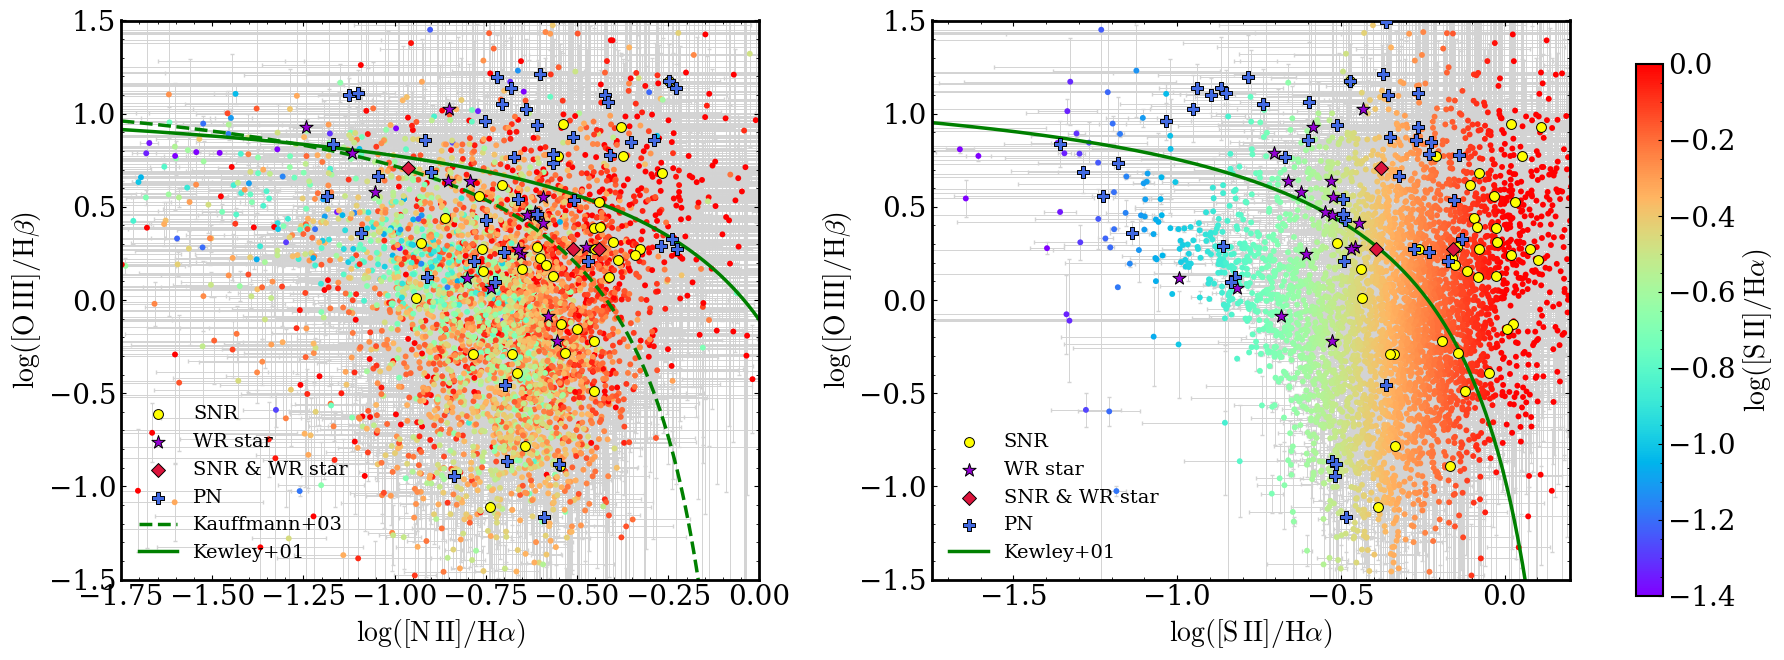

Using third color: True


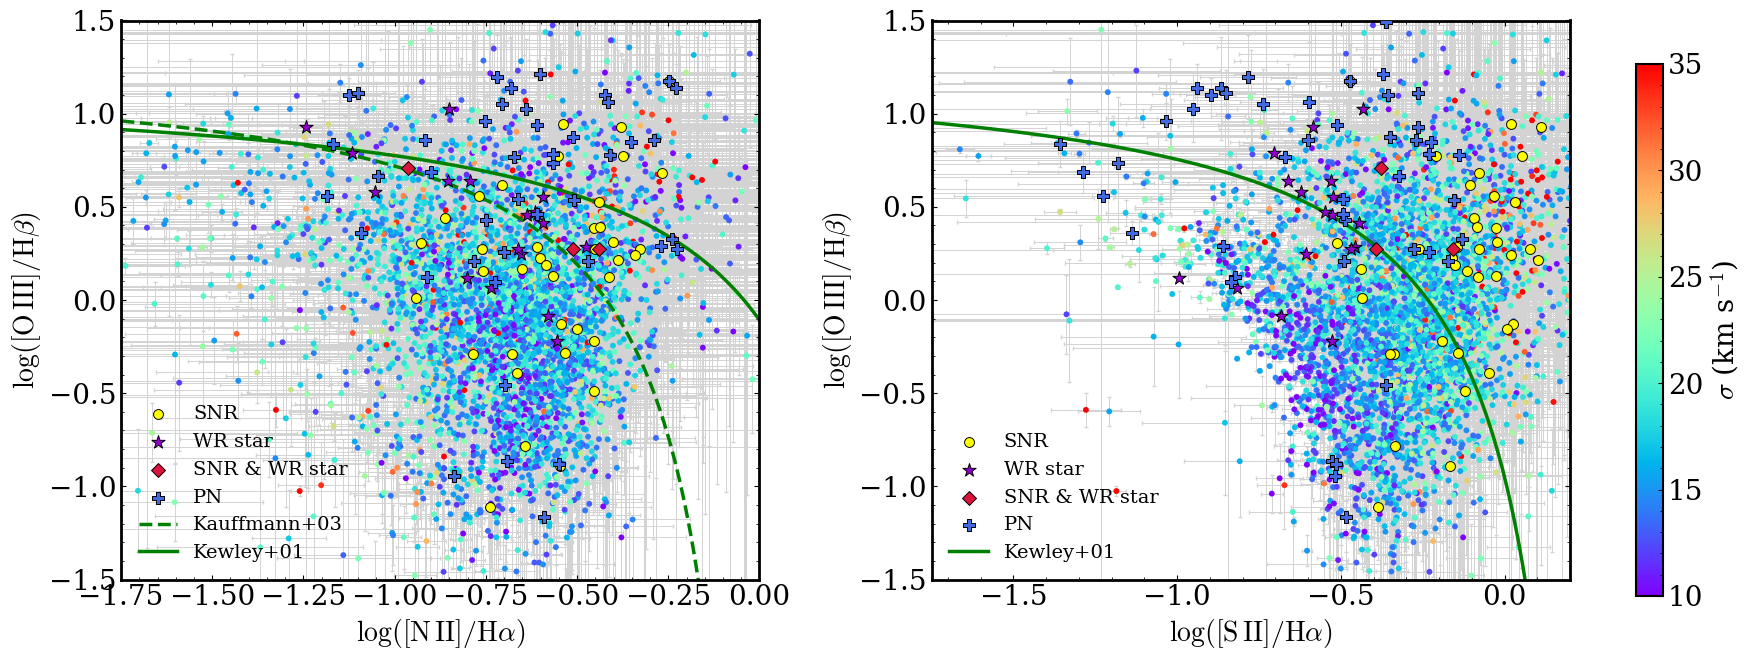

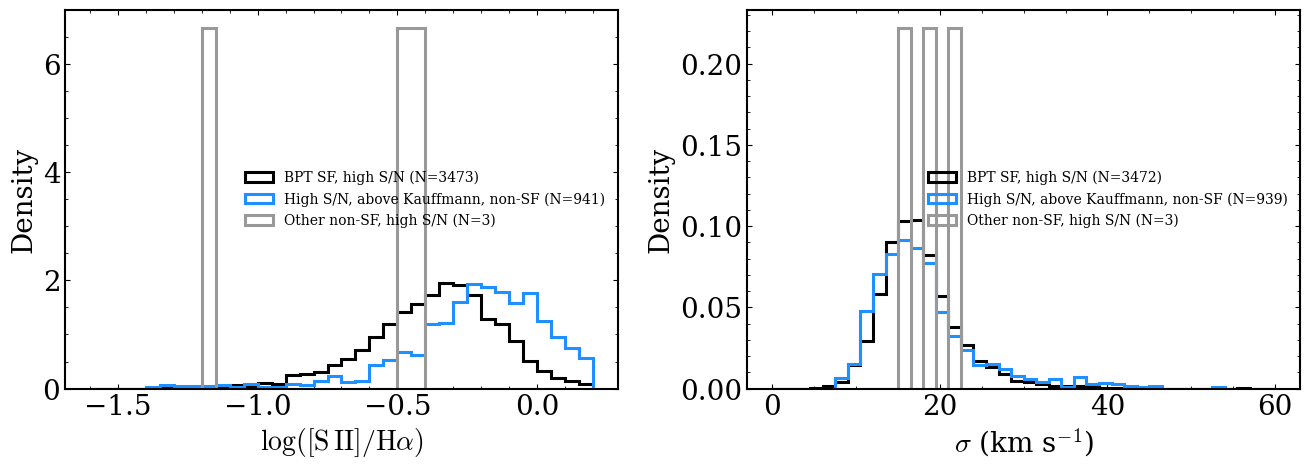

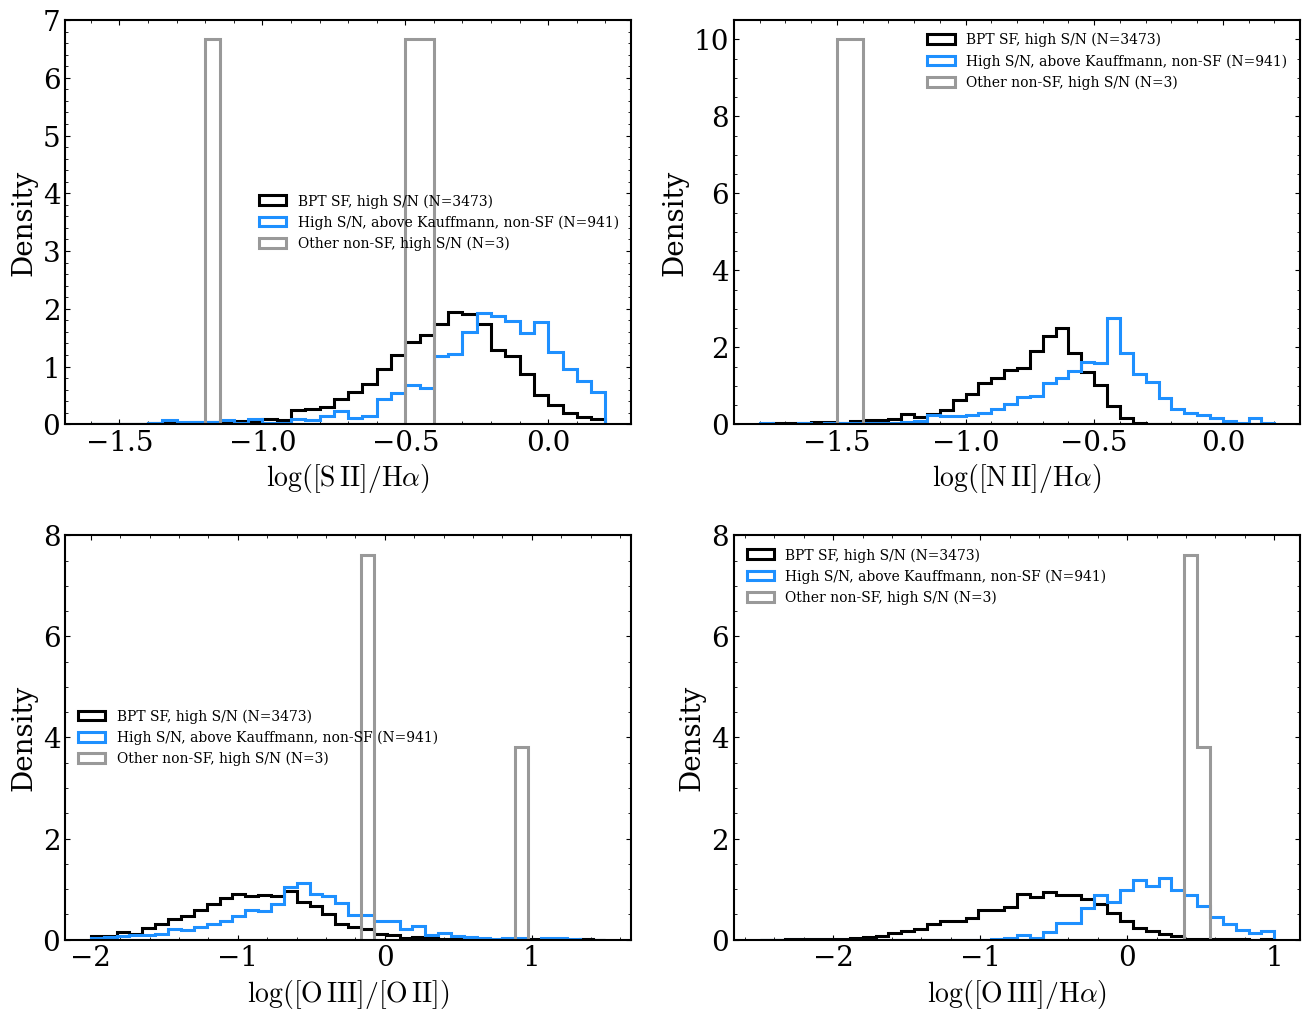

High-S/N, above-Kauffmann, non-SF candidates: 941
Wrote candidate table: PAPER_PLOTS/summed_map/dig_subtracted/bpt/M33_BPT_high_snr_above_kauffmann_non_SF_candidates.csv


In [13]:
# BPT diagnostic versions and distributions for testing SF-region selection cuts.
snr_cut = BPT_DIAGNOSTIC_SNR_CUT
cat = add_bpt_diagnostic_columns(cat, snr_cut=snr_cut)
cat_bpt_sf_gray = cat.copy()
cat_bpt_sf_gray['bpt_sf_display'] = np.where(selected_star_forming_mask(cat_bpt_sf_gray), 1.0, 0.0)

bpt_sii_ha_path = paper_plot_path(
    f'M33_allfields_BPT_SNR{snr_cut:g}_colored_by_SII_Halpha_ratio_compact_objects.png',
    subdir='bpt',
)
plot_bpt(
    cat_bpt_sf_gray,
    snr_cut=snr_cut,
    marker_size=18,
    color_col='log_SII_Halpha',
    cmap='rainbow',
    vmin=-1.4,
    vmax=0.0,
    colorbar_log=False,
    colorbar_label=r'$\log([\mathrm{S\,II}]/\mathrm{H}\alpha)$',
    highlight_wr_snr=True,
    flagged_size_factor=2.8,
    ratio_pairs=[
        ('NII_Ha', 'OIII_Hb'),
        ('SII_Ha', 'OIII_Hb'),
    ],
    savepath=str(bpt_sii_ha_path),
)

bpt_velocity_dispersion_path = paper_plot_path(
    f'M33_allfields_BPT_SNR{snr_cut:g}_colored_by_velocity_dispersion_compact_objects.png',
    subdir='bpt',
)
plot_bpt(
    cat_bpt_sf_gray,
    snr_cut=snr_cut,
    marker_size=18,
    color_col='sigma_mean_kms',
    cmap='rainbow',
    vmin=10,
    vmax=35,
    colorbar_log=False,
    colorbar_label=r'$\sigma$ (km s$^{-1}$)',
    highlight_wr_snr=True,
    flagged_size_factor=2.8,
    ratio_pairs=[
        ('NII_Ha', 'OIII_Hb'),
        ('SII_Ha', 'OIII_Hb'),
    ],
    savepath=str(bpt_velocity_dispersion_path),
)


def _finite_series_for_hist(df, column):
    values = pd.to_numeric(df[column], errors='coerce').to_numpy(dtype=float)
    return values[np.isfinite(values)]


def _hist_by_population(ax, df, column, bins, xlabel):
    bpt_sf = selected_star_forming_mask(df)
    blue = df['high_snr_above_kauffmann_non_sf'].fillna(False).astype(bool).to_numpy()
    high_snr = df['high_snr_nii_bpt'].fillna(False).astype(bool).to_numpy() if 'high_snr_nii_bpt' in df.columns else np.ones(len(df), dtype=bool)
    populations = [
        (bpt_sf & high_snr, 'black', 'BPT SF, high S/N'),
        (blue, 'dodgerblue', 'High S/N, above Kauffmann, non-SF'),
        ((~bpt_sf) & high_snr & ~blue, '0.60', 'Other non-SF, high S/N'),
    ]
    for mask, color, label in populations:
        values = pd.to_numeric(df.loc[mask, column], errors='coerce').to_numpy(dtype=float)
        values = values[np.isfinite(values)]
        if values.size == 0:
            continue
        ax.hist(values, bins=bins, histtype='step', linewidth=2.2, density=True, color=color, label=f'{label} (N={values.size})')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Density')
    ax.minorticks_on()
    ax.legend(frameon=False, fontsize=10)


fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.2))
_hist_by_population(
    axes[0], cat, 'log_SII_Halpha',
    bins=np.linspace(-1.6, 0.2, 37),
    xlabel=r'$\log([\mathrm{S\,II}]/\mathrm{H}\alpha)$',
)
if 'sigma_mean_kms' in cat.columns:
    _hist_by_population(
        axes[1], cat, 'sigma_mean_kms',
        bins=np.linspace(0, 60, 41),
        xlabel=r'$\sigma$ (km s$^{-1}$)',
    )
else:
    axes[1].text(0.5, 0.5, 'sigma_mean_kms not available\nRun notebook 7 kinematic update first.', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_axis_off()
fig.tight_layout()
fig.savefig(paper_plot_path('M33_BPT_candidate_SII_Halpha_sigma_histograms.png', subdir='bpt'), dpi=300, bbox_inches='tight')
plt.show()

ratio_distribution_specs = [
    ('log_SII_Halpha', r'$\log([\mathrm{S\,II}]/\mathrm{H}\alpha)$', np.linspace(-1.6, 0.2, 37)),
    ('log_NII_Halpha', r'$\log([\mathrm{N\,II}]/\mathrm{H}\alpha)$', np.linspace(-1.8, 0.2, 41)),
    ('log_OIII_OII', r'$\log([\mathrm{O\,III}]/[\mathrm{O\,II}])$', np.linspace(-2.0, 1.5, 41)),
    ('log_OIII_Halpha', r'$\log([\mathrm{O\,III}]/\mathrm{H}\alpha)$', np.linspace(-2.5, 1.0, 41)),
]
fig, axes = plt.subplots(2, 2, figsize=(13.5, 10.5))
for ax, (column, xlabel, bins) in zip(axes.ravel(), ratio_distribution_specs):
    _hist_by_population(ax, cat, column, bins=bins, xlabel=xlabel)
fig.tight_layout()
fig.savefig(paper_plot_path('M33_BPT_candidate_line_ratio_distributions.png', subdir='bpt'), dpi=300, bbox_inches='tight')
plt.show()

blue_candidates = cat.loc[cat['high_snr_above_kauffmann_non_sf'].fillna(False)].copy()
blue_candidates_path = paper_plot_path('M33_BPT_high_snr_above_kauffmann_non_SF_candidates.csv', subdir='bpt')
summary_cols = [
    'field', 'region_id', 'RA_deg', 'Dec_deg', 'BPT_class_sum_dered',
    'log_SII_Halpha', 'log_NII_Halpha', 'log_OIII_OII', 'log_OIII_Halpha',
    'log_OIII_Hbeta', 'sigma_mean_kms', 'SNR_Halpha_sum', 'SNR_[OIII]5007_sum',
]
summary_cols = [col for col in summary_cols if col in blue_candidates.columns]
blue_candidates[summary_cols].to_csv(blue_candidates_path, index=False)
print(f'High-S/N, above-Kauffmann, non-SF candidates: {len(blue_candidates)}')
print(f'Wrote candidate table: {blue_candidates_path}')



Plotting class_snr3_only: {'snr3_all_lines': 4417, 'low_snr': 1485}


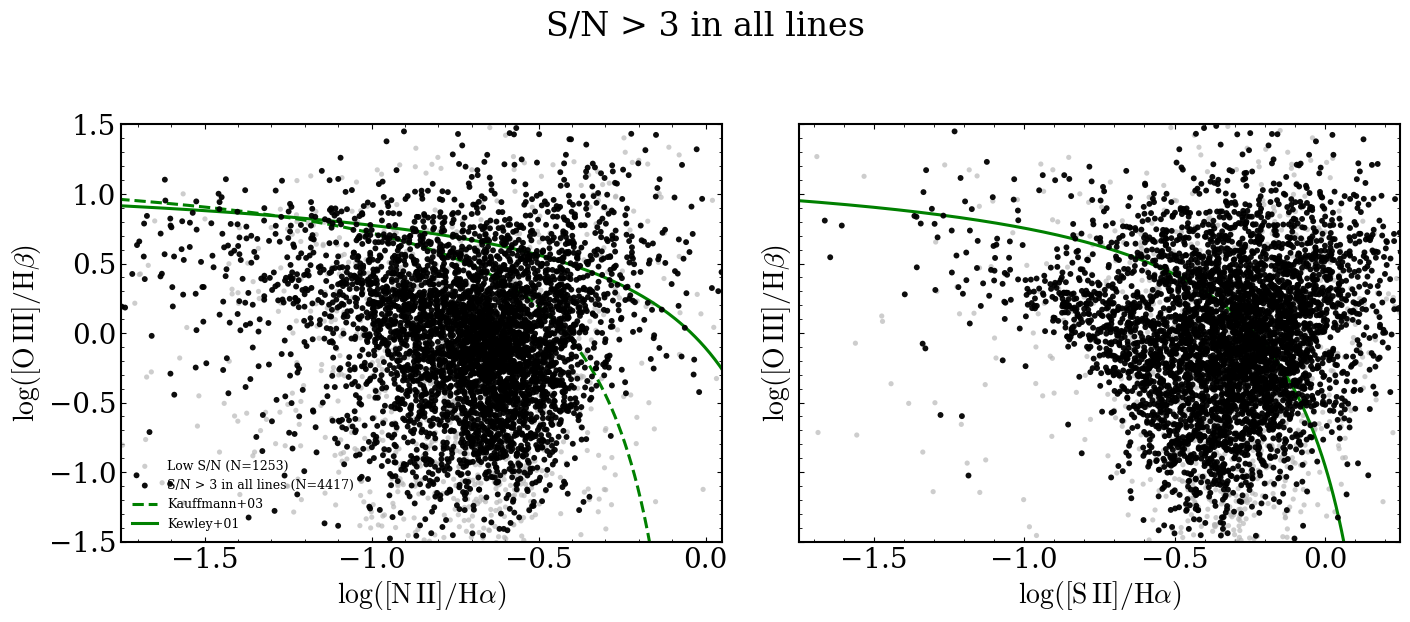

Plotting class_bpt_snr3_nonbpt: {'bpt_sf_snr3': 3473, 'low_snr': 1485, 'snr3_non_bpt_sf': 944}


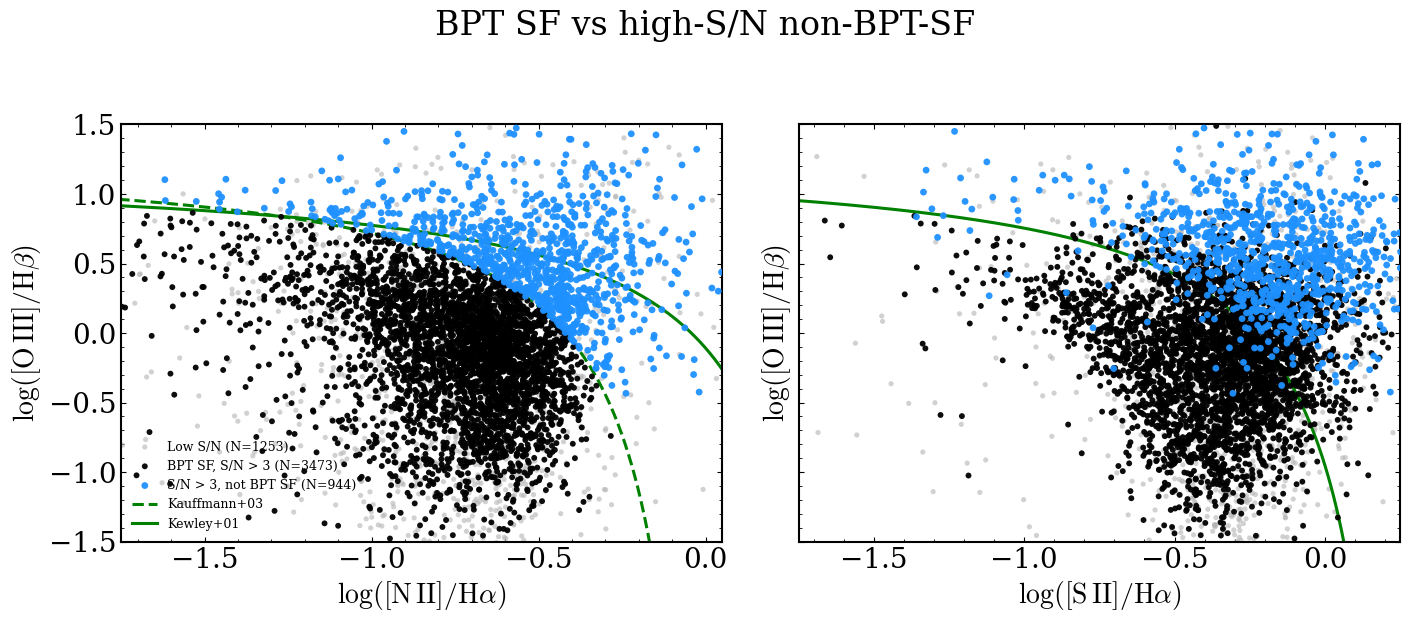

Plotting class_bpt_snr3_nonbpt_snr50: {'bpt_sf_snr3': 3473, 'low_snr': 1485, 'snr3_non_bpt_sf': 879, 'snr50_non_bpt_sf': 65}


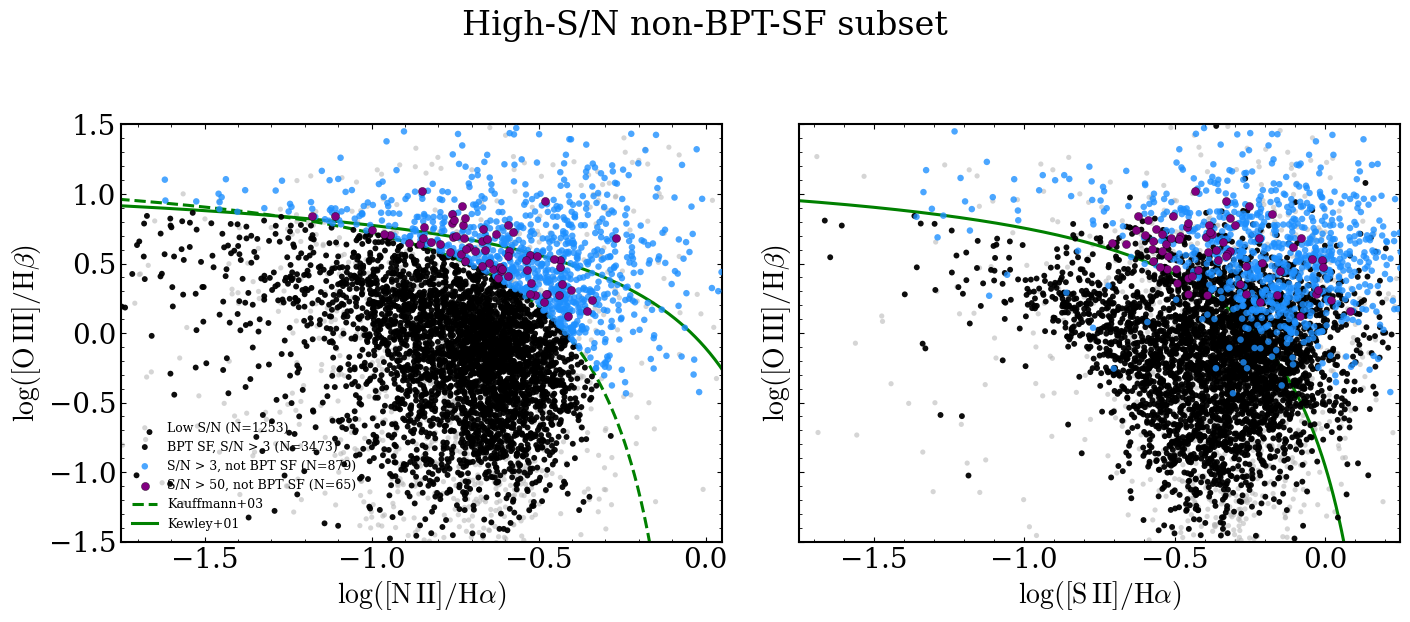

Plotting class_custom_sf: {'bpt_sf_snr3': 3473, 'low_snr': 1485, 'snr3_non_custom_sf': 843, 'recovered_siiha_sf': 101}


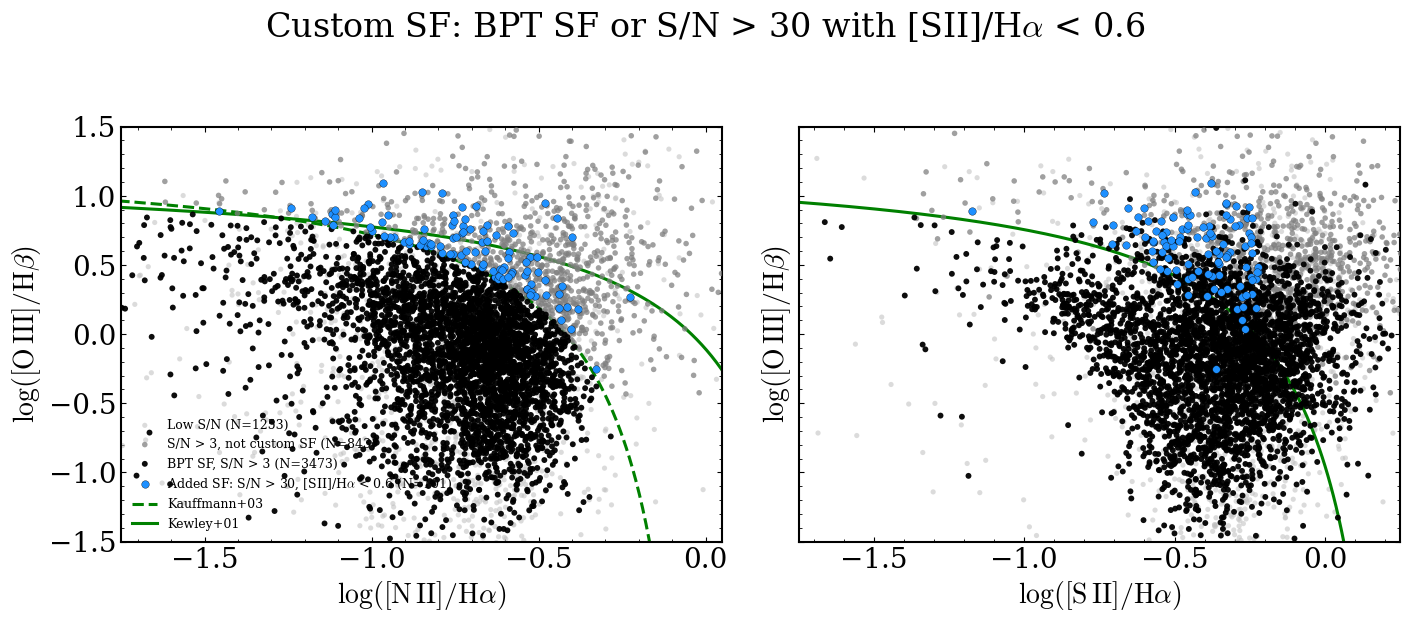

In [14]:
# Matching categorical BPT diagrams for the all-field map classification versions.
cat = add_bpt_diagnostic_columns(cat, snr_cut=BPT_DIAGNOSTIC_SNR_CUT)


def _draw_nii_bpt_demarcations(ax):
    x_vals = np.linspace(-2.0, 0.45, 500)
    kauff_mask = x_vals < 0.05
    kewley_mask = x_vals < 0.47
    ax.plot(x_vals[kauff_mask], 0.61 / (x_vals[kauff_mask] - 0.05) + 1.3, 'g--', lw=2.2, label='Kauffmann+03')
    ax.plot(x_vals[kewley_mask], 0.61 / (x_vals[kewley_mask] - 0.47) + 1.19, 'g-', lw=2.2, label='Kewley+01')
    ax.set_xlim(-1.75, 0.05)
    ax.set_ylim(-1.5, 1.5)


def _draw_sii_bpt_demarcations(ax):
    x_vals = np.linspace(-2.0, 0.3, 500)
    kewley_mask = x_vals < 0.32
    ax.plot(x_vals[kewley_mask], 0.72 / (x_vals[kewley_mask] - 0.32) + 1.30, 'g-', lw=2.2, label='Kewley+01')
    ax.set_xlim(-1.75, 0.25)
    ax.set_ylim(-1.5, 1.5)


def plot_categorical_bpt(df, category_col, category_styles, savepath=None, title=None):
    fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.2), sharey=True)
    panel_specs = [
        (axes[0], 'log_NII_Halpha', 'log_OIII_Hbeta', r'$\log([\mathrm{N\,II}]/\mathrm{H}\alpha)$', r'$\log([\mathrm{O\,III}]/\mathrm{H}\beta)$', _draw_nii_bpt_demarcations),
        (axes[1], 'log_SII_Halpha', 'log_OIII_Hbeta', r'$\log([\mathrm{S\,II}]/\mathrm{H}\alpha)$', r'$\log([\mathrm{O\,III}]/\mathrm{H}\beta)$', _draw_sii_bpt_demarcations),
    ]
    for ax, x_col, y_col, xlabel, ylabel, draw_lines in panel_specs:
        x = pd.to_numeric(df[x_col], errors='coerce').to_numpy(dtype=float)
        y = pd.to_numeric(df[y_col], errors='coerce').to_numpy(dtype=float)
        valid = np.isfinite(x) & np.isfinite(y)
        for category, style in category_styles.items():
            select = valid & df[category_col].astype(str).eq(str(category)).to_numpy()
            if not np.any(select):
                continue
            ax.scatter(
                x[select], y[select],
                s=style.get('s', 18),
                c=style.get('color', '0.6'),
                marker=style.get('marker', 'o'),
                edgecolors=style.get('edgecolor', 'none'),
                linewidths=style.get('linewidth', 0.0),
                alpha=style.get('alpha', 0.9),
                label=f"{style.get('label', str(category))} (N={int(select.sum())})",
                zorder=style.get('zorder', 3),
            )
        draw_lines(ax)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.minorticks_on()
        ax.tick_params(direction='in', which='both', top=True, right=True)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
    handles, labels = axes[0].get_legend_handles_labels()
    unique = dict(zip(labels, handles))
    axes[0].legend(unique.values(), unique.keys(), frameon=False, loc='lower left', fontsize=9)
    if title:
        fig.suptitle(title, y=1.02)
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, axes

classification_bpt_specs = [
    dict(
        category_col='class_snr3_only',
        filename='M33_BPT_snr3_all_lines_black_low_snr_gray.png',
        title='S/N > 3 in all lines',
        styles={
            'low_snr': {'color': '0.70', 's': 14, 'alpha': 0.65, 'zorder': 2, 'label': 'Low S/N'},
            'snr3_all_lines': {'color': 'black', 's': 18, 'alpha': 0.95, 'zorder': 4, 'label': 'S/N > 3 in all lines'},
        },
    ),
    dict(
        category_col='class_bpt_snr3_nonbpt',
        filename='M33_BPT_bpt_sf_black_snr3_nonbpt_blue_low_snr_gray.png',
        title='BPT SF vs high-S/N non-BPT-SF',
        styles={
            'low_snr': {'color': '0.70', 's': 14, 'alpha': 0.60, 'zorder': 2, 'label': 'Low S/N'},
            'bpt_sf_snr3': {'color': 'black', 's': 18, 'alpha': 0.95, 'zorder': 4, 'label': 'BPT SF, S/N > 3'},
            'snr3_non_bpt_sf': {'color': 'dodgerblue', 's': 24, 'alpha': 0.95, 'zorder': 5, 'label': 'S/N > 3, not BPT SF'},
        },
    ),
    dict(
        category_col='class_bpt_snr3_nonbpt_snr50',
        filename='M33_BPT_bpt_sf_black_snr3_blue_snr50_purple_low_snr_gray.png',
        title='High-S/N non-BPT-SF subset',
        styles={
            'low_snr': {'color': '0.70', 's': 14, 'alpha': 0.55, 'zorder': 2, 'label': 'Low S/N'},
            'bpt_sf_snr3': {'color': 'black', 's': 18, 'alpha': 0.95, 'zorder': 4, 'label': 'BPT SF, S/N > 3'},
            'snr3_non_bpt_sf': {'color': 'dodgerblue', 's': 22, 'alpha': 0.80, 'zorder': 5, 'label': 'S/N > 3, not BPT SF'},
            'snr50_non_bpt_sf': {'color': 'purple', 's': 34, 'alpha': 1.0, 'edgecolor': 'black', 'linewidth': 0.25, 'zorder': 6, 'label': 'S/N > 50, not BPT SF'},
        },
    ),
    dict(
        category_col='class_custom_sf',
        filename='M33_BPT_custom_sf_bpt_or_siiha.png',
        title=r'Custom SF: BPT SF or S/N > 30 with [SII]/H$\alpha$ < 0.6',
        styles={
            'low_snr': {'color': '0.75', 's': 14, 'alpha': 0.55, 'zorder': 2, 'label': 'Low S/N'},
            'snr3_non_custom_sf': {'color': '0.50', 's': 16, 'alpha': 0.75, 'zorder': 3, 'label': 'S/N > 3, not custom SF'},
            'bpt_sf_snr3': {'color': 'black', 's': 18, 'alpha': 0.95, 'zorder': 5, 'label': 'BPT SF, S/N > 3'},
            'recovered_siiha_sf': {'color': 'dodgerblue', 's': 30, 'alpha': 1.0, 'edgecolor': 'black', 'linewidth': 0.25, 'zorder': 6, 'label': r'Added SF: S/N > 30, [SII]/H$\alpha$ < 0.6'},
        },
    ),
]

for spec in classification_bpt_specs:
    print(f"Plotting {spec['category_col']}:", cat[spec['category_col']].value_counts().to_dict())
    plot_categorical_bpt(
        cat,
        category_col=spec['category_col'],
        category_styles=spec['styles'],
        title=spec['title'],
        savepath=str(paper_plot_path(spec['filename'], subdir='bpt')),
    )



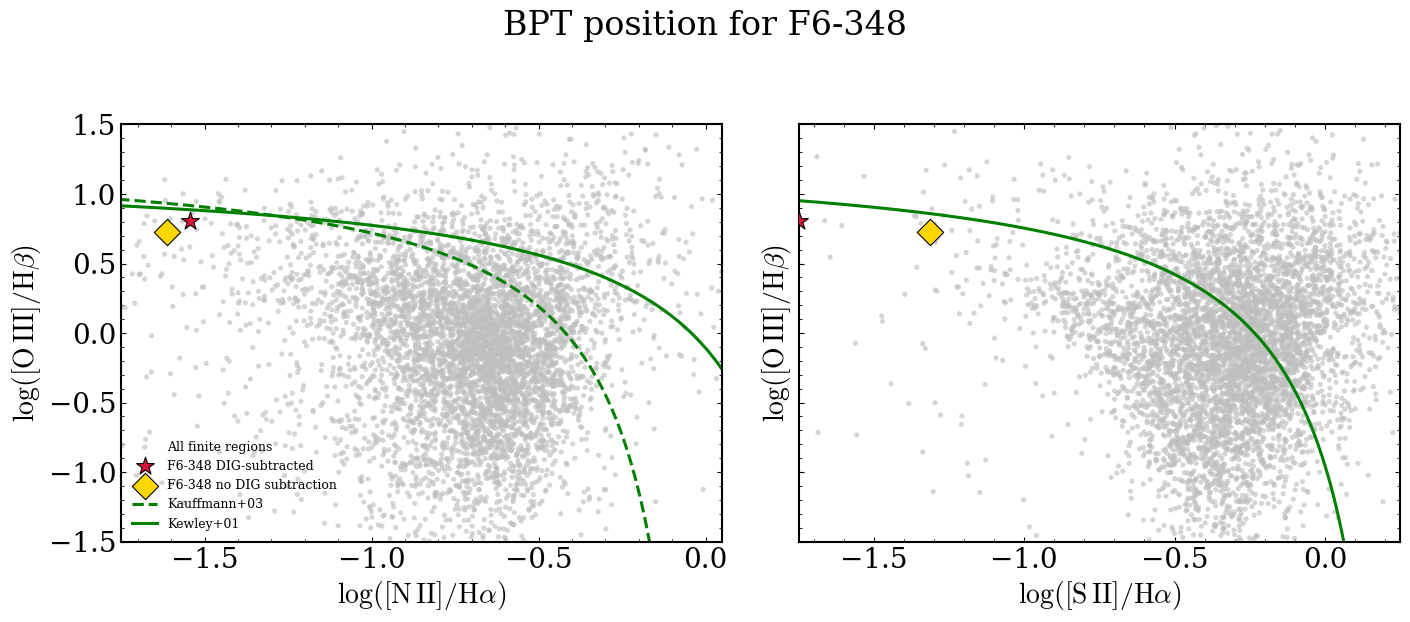

field                                 F6
region_id                            348
x                                   1137
y                                   1953
BPT_class_sum_dered         Star-forming
SNR_Halpha_sum               1476.880024
SNR_Hbeta_sum                 230.951113
SNR_[OIII]5007_sum            863.147237
SNR_[NII]6583_sum              56.405523
SNR_[SII]6716_sum              61.669847
SNR_[SII]6731_sum               40.55369
SNR_[OII]3727_sum             169.038479
SNR_Halpha_sum_nodig         1476.880024
SNR_Hbeta_sum_nodig           230.951113
SNR_[OIII]5007_sum_nodig      863.147237
SNR_[NII]6583_sum_nodig        56.405523
SNR_[SII]6716_sum_nodig        61.669847
SNR_[SII]6731_sum_nodig         40.55369
SNR_[OII]3727_sum_nodig       169.038479
DIG-subtracted BPT ratios: {'NII_Ha': -1.542660656102016, 'SII_Ha': -1.748890118929104, 'OIII_Hb': 0.8085815533076641, 'NII_flux': 1.7459729453434125e-14, 'Halpha_flux': 6.091134171080529e-13}
No-DIG BPT ratios: {'NII_Ha'

In [15]:
# Diagnostic BPT highlight for the bright F6 top-middle region with low all-line S/N.
# Region F6-348 is bright in Halpha and [OIII], but fails the all-line S/N cut because
# its DIG-subtracted [NII] flux is negative. This plot compares the active DIG-subtracted
# ratios to the no-DIG ratios for that region.
BPT_DIAGNOSTIC_REGION = {'field': 'F6', 'region_id': 348}


def _line_flux_for_suffix(df, line_name, suffix):
    candidates = [
        f'F_{line_name}_{suffix}',
        f'F_{line_name}_sum_{suffix}',
        f'F_{line_name}_sum',
    ]
    for col in candidates:
        if col in df.columns:
            return pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float), col
    return np.full(len(df), np.nan, dtype=float), None


def _single_log_ratio(row, num_col, den_col):
    num = pd.to_numeric(pd.Series([row.get(num_col, np.nan)]), errors='coerce').iloc[0]
    den = pd.to_numeric(pd.Series([row.get(den_col, np.nan)]), errors='coerce').iloc[0]
    if not np.isfinite(num) or not np.isfinite(den) or num <= 0 or den <= 0:
        return np.nan
    return float(np.log10(num / den))


def _ratio_columns_for_mode(line_name, mode):
    if mode == 'digsub':
        return f'F_{line_name}_sum_digsub'
    if mode == 'nodig':
        return f'F_{line_name}_sum_nodig'
    raise ValueError(mode)


def _region_bpt_point(row, mode='digsub'):
    ha = _ratio_columns_for_mode('Halpha', mode)
    hb = _ratio_columns_for_mode('Hbeta', mode)
    oiii = _ratio_columns_for_mode('[OIII]5007', mode)
    nii = _ratio_columns_for_mode('[NII]6583', mode)
    sii6716 = _ratio_columns_for_mode('[SII]6716', mode)
    sii6731 = _ratio_columns_for_mode('[SII]6731', mode)

    sii_sum = np.nan
    sii6716_val = pd.to_numeric(pd.Series([row.get(sii6716, np.nan)]), errors='coerce').iloc[0]
    sii6731_val = pd.to_numeric(pd.Series([row.get(sii6731, np.nan)]), errors='coerce').iloc[0]
    if np.isfinite(sii6716_val) and np.isfinite(sii6731_val):
        sii_sum = sii6716_val + sii6731_val
    ha_val = pd.to_numeric(pd.Series([row.get(ha, np.nan)]), errors='coerce').iloc[0]
    hb_val = pd.to_numeric(pd.Series([row.get(hb, np.nan)]), errors='coerce').iloc[0]
    oiii_val = pd.to_numeric(pd.Series([row.get(oiii, np.nan)]), errors='coerce').iloc[0]
    nii_val = pd.to_numeric(pd.Series([row.get(nii, np.nan)]), errors='coerce').iloc[0]

    def _log(num, den):
        if not np.isfinite(num) or not np.isfinite(den) or num <= 0 or den <= 0:
            return np.nan
        return float(np.log10(num / den))

    return {
        'NII_Ha': _log(nii_val, ha_val),
        'SII_Ha': _log(sii_sum, ha_val),
        'OIII_Hb': _log(oiii_val, hb_val),
        'NII_flux': nii_val,
        'Halpha_flux': ha_val,
    }


def plot_region_bpt_highlight(df, field='F6', region_id=348, savepath=None):
    work = add_bpt_diagnostic_columns(df, snr_cut=BPT_DIAGNOSTIC_SNR_CUT)
    region_mask = work['field'].astype(str).eq(str(field)) & (pd.to_numeric(work['region_id'], errors='coerce') == int(region_id))
    if not region_mask.any():
        raise ValueError(f'Region {field}-{region_id} not found in catalog.')
    row = work.loc[region_mask].iloc[0]
    active = _region_bpt_point(row, mode='digsub')
    nodig = _region_bpt_point(row, mode='nodig')

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.2), sharey=True)
    panel_specs = [
        (axes[0], 'log_NII_Halpha', 'log_OIII_Hbeta', 'NII_Ha', r'$\log([\mathrm{N\,II}]/\mathrm{H}\alpha)$', r'$\log([\mathrm{O\,III}]/\mathrm{H}\beta)$', _draw_nii_bpt_demarcations),
        (axes[1], 'log_SII_Halpha', 'log_OIII_Hbeta', 'SII_Ha', r'$\log([\mathrm{S\,II}]/\mathrm{H}\alpha)$', r'$\log([\mathrm{O\,III}]/\mathrm{H}\beta)$', _draw_sii_bpt_demarcations),
    ]
    for ax, x_col, y_col, point_x_key, xlabel, ylabel, draw_lines in panel_specs:
        x = pd.to_numeric(work[x_col], errors='coerce').to_numpy(dtype=float)
        y = pd.to_numeric(work[y_col], errors='coerce').to_numpy(dtype=float)
        valid = np.isfinite(x) & np.isfinite(y)
        ax.scatter(x[valid], y[valid], s=14, c='0.75', edgecolors='none', alpha=0.65, label='All finite regions', zorder=2)
        for point, color, marker, label, zorder in [
            (active, 'crimson', '*', f'{field}-{region_id} DIG-subtracted', 6),
            (nodig, 'gold', 'D', f'{field}-{region_id} no DIG subtraction', 5),
        ]:
            px = point[point_x_key]
            py = point['OIII_Hb']
            if np.isfinite(px) and np.isfinite(py):
                ax.scatter([px], [py], s=180, c=color, marker=marker, edgecolors='black', linewidths=0.8, label=label, zorder=zorder)
            else:
                ax.text(0.03, 0.94 if label.endswith('DIG-subtracted') else 0.88,
                        f'{label}: not finite on this panel', transform=ax.transAxes, fontsize=10, color=color)
        draw_lines(ax)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.minorticks_on()
        ax.tick_params(direction='in', which='both', top=True, right=True)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)
    handles, labels = axes[0].get_legend_handles_labels()
    handles2, labels2 = axes[1].get_legend_handles_labels()
    unique = dict(zip(labels + labels2, handles + handles2))
    axes[0].legend(unique.values(), unique.keys(), frameon=False, loc='lower left', fontsize=9)
    fig.suptitle(f'BPT position for {field}-{region_id}', y=1.02)
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.show()

    snr_cols = [
        'SNR_Halpha_sum', 'SNR_Hbeta_sum', 'SNR_[OIII]5007_sum',
        'SNR_[NII]6583_sum', 'SNR_[SII]6716_sum', 'SNR_[SII]6731_sum',
        'SNR_[OII]3727_sum',
        'SNR_Halpha_sum_nodig', 'SNR_Hbeta_sum_nodig', 'SNR_[OIII]5007_sum_nodig',
        'SNR_[NII]6583_sum_nodig', 'SNR_[SII]6716_sum_nodig', 'SNR_[SII]6731_sum_nodig',
        'SNR_[OII]3727_sum_nodig',
    ]
    print(row[['field', 'region_id', 'x', 'y', 'BPT_class_sum_dered'] + [c for c in snr_cols if c in row.index]].to_string())
    print('DIG-subtracted BPT ratios:', active)
    print('No-DIG BPT ratios:', nodig)
    return fig, axes, row


fig_f6_348_bpt, axes_f6_348_bpt, f6_348_row = plot_region_bpt_highlight(
    cat,
    field=BPT_DIAGNOSTIC_REGION['field'],
    region_id=BPT_DIAGNOSTIC_REGION['region_id'],
    savepath=str(paper_plot_path('M33_BPT_highlight_F6_348_bright_lowSNR_region.png', subdir='bpt')),
)



In [16]:
# BPT + mosaic diagnostic for high-Halpha-S/N non-star-forming regions.
# These are regions that are not classified as star-forming but have Halpha S/N > 30.

high_halpha_snr_threshold = 50.0
bpt_high_snr_blue = 'dodgerblue'


def _flux_values_for_bpt(df, line_name):
    col = _first_present_column(df, [
        f'F_{line_name}_sum_dered',
        f'F_{line_name}_sum_digsub',
        f'F_{line_name}_sum',
        f'F_{line_name}_sum_nodig',
    ])
    if col is None:
        raise KeyError(f'No flux column found for {line_name}')
    return pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=float), col


def _bpt_log_ratio(num, den):
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.asarray(num, dtype=float) / np.asarray(den, dtype=float)
        out = np.log10(ratio)
    return np.where(np.isfinite(out) & (np.asarray(num) > 0) & (np.asarray(den) > 0), out, np.nan)


def _draw_nii_bpt_lines(ax):
    x_vals = np.linspace(-2.0, 0.45, 500)
    kauff_mask = x_vals < 0.05
    kewley_mask = x_vals < 0.47
    ax.plot(x_vals[kauff_mask], 0.61 / (x_vals[kauff_mask] - 0.05) + 1.3, 'g--', lw=2.2, label='Kauffmann+03')
    ax.plot(x_vals[kewley_mask], 0.61 / (x_vals[kewley_mask] - 0.47) + 1.19, 'g-', lw=2.2, label='Kewley+01')
    ax.set_xlim(-1.75, 0.0)
    ax.set_ylim(-1.5, 1.5)


def _draw_sii_bpt_lines(ax):
    x_vals = np.linspace(-2.0, 0.3, 500)
    kewley_mask = x_vals < 0.32
    ax.plot(x_vals[kewley_mask], 0.72 / (x_vals[kewley_mask] - 0.32) + 1.30, 'g-', lw=2.2, label='Kewley+01')
    ax.set_xlim(-1.75, 0.2)
    ax.set_ylim(-1.5, 1.5)


def plot_bpt_high_halpha_snr_non_sf(df, snr_threshold=30.0, savepath=None):
    work = df.copy()
    primary = work['primary'].fillna(True).astype(bool).to_numpy() if 'primary' in work.columns else np.ones(len(work), dtype=bool)
    sf_snr3 = selected_star_forming_snr_mask(work, snr_cut=3.0)
    high_snr_non_sf = _high_halpha_snr_non_sf_mask_for_plotting(work, snr_threshold=snr_threshold)
    halpha_snr, halpha_snr_col = _halpha_snr_values_for_plotting(work)

    ha, _ = _flux_values_for_bpt(work, 'Halpha')
    hb, _ = _flux_values_for_bpt(work, 'Hbeta')
    nii, _ = _flux_values_for_bpt(work, '[NII]6583')
    oiii, _ = _flux_values_for_bpt(work, '[OIII]5007')
    sii6716, _ = _flux_values_for_bpt(work, '[SII]6716')
    sii6731, _ = _flux_values_for_bpt(work, '[SII]6731')
    sii = sii6716 + sii6731

    x_nii = _bpt_log_ratio(nii, ha)
    x_sii = _bpt_log_ratio(sii, ha)
    y_oiii = _bpt_log_ratio(oiii, hb)

    panel_specs = [
        (x_nii, y_oiii, r'$\log([\mathrm{N\,II}]/\mathrm{H}\alpha)$', r'$\log([\mathrm{O\,III}]/\mathrm{H}\beta)$', _draw_nii_bpt_lines),
        (x_sii, y_oiii, r'$\log([\mathrm{S\,II}]/\mathrm{H}\alpha)$', r'$\log([\mathrm{O\,III}]/\mathrm{H}\beta)$', _draw_sii_bpt_lines),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.4), sharey=True)
    for ax, (x, y, xlabel, ylabel, draw_lines) in zip(axes, panel_specs):
        valid = np.isfinite(x) & np.isfinite(y)
        other = valid & ~sf_snr3 & ~high_snr_non_sf
        sf = valid & sf_snr3
        blue = valid & high_snr_non_sf

        ax.scatter(x[other], y[other], s=16, c='0.68', edgecolors='none', alpha=0.85, label='Other regions', zorder=2)
        ax.scatter(x[sf], y[sf], s=18, c='black', edgecolors='none', alpha=0.95, label='Selected SF, S/N>3', zorder=3)
        ax.scatter(x[blue], y[blue], s=34, c=bpt_high_snr_blue, edgecolors='black', linewidths=0.35, alpha=1.0,
                   label=rf'Non-SF, H$\alpha$ S/N $>$ {snr_threshold:.0f}', zorder=5)
        draw_lines(ax)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.minorticks_on()
        ax.tick_params(direction='in', which='both', top=True, right=True)
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

    handles, labels = axes[0].get_legend_handles_labels()
    # Keep one entry per label while preserving plotted order.
    unique = dict(zip(labels, handles))
    axes[0].legend(unique.values(), unique.keys(), frameon=False, loc='lower left', fontsize=11)
    fig.tight_layout()
    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')
    plt.close(fig)

    print(
        f"High-Halpha-S/N non-SF regions: {int(high_snr_non_sf.sum())} "
        f"using {halpha_snr_col} > {snr_threshold:.0f}."
    )
    return fig, axes, work.loc[high_snr_non_sf].copy()


bpt_high_halpha_snr_path = paper_plot_path(
    f'M33_allfields_BPT_SNR_non_SF_blue_SNRgt{int(high_halpha_snr_threshold)}.png',
    subdir='bpt',
)
fig_bpt_high_snr, axes_bpt_high_snr, high_halpha_snr_non_sf_regions = plot_bpt_high_halpha_snr_non_sf(
    cat,
    snr_threshold=high_halpha_snr_threshold,
    savepath=str(bpt_high_halpha_snr_path),
)

plot_m33_boundary_mosaic(
    field_order=mosaic_field_order,
    halpha_only_fields=("F9",),
    combined_catalog=cat,
    pn_catalog=pn_catalog,
    boundary_color_mode='sf_snr3_high_halpha_snr_non_sf',
    boundary_color='black',
    other_region_color='0.62',
    cmap='rainbow',
    boundary_lw=0.45,
    boundary_alpha=0.80,
    wr_color='darkviolet',
    snr_color='yellow',
    pn_color='royalblue',
    wr_marker_size=18,
    snr_marker_size=6,
    pn_marker_size=9,
    field_valid_bounds=(50, 2000, 50, 2000),
    display_field_valid_bounds=(50, 2000, 50, 2000),
    display_field_edge_margin=None,
    fill_mosaic_gaps_from_field_maps=True,
    show_field_labels=True,
    field_label_corner='upper left',
    field_label_pad_pixels=90,
    field_label_fontsize=15,
    axis_label_fontsize=15,
    tick_label_fontsize=15,
    colorbar_fontsize=15,
    colorbar_tick_labelsize=15,
    savepath=str(paper_plot_path(
        f'M33_all_fields_boundary_mosaic_SNR_non_SF_blue_SNRgt{int(high_halpha_snr_threshold)}.png',
        subdir='field_maps',
    )),
    save_dpi=500,
)


High-Halpha-S/N non-SF regions: 748 using SNR_Halpha_sum > 50.
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.


(<Figure size 1200x1600 with 2 Axes>, <WCSAxes: >)

In [17]:
# Mosaic map highlighting high-S/N, above-Kauffmann, non-SF candidates in blue.
# This uses the same high_snr_above_kauffmann_non_sf flag as the 8b BPT/histogram diagnostics.
cat = add_bpt_diagnostic_columns(cat, snr_cut=BPT_DIAGNOSTIC_SNR_CUT)
print(f"High-S/N, above-Kauffmann, non-SF regions: {int(cat['high_snr_above_kauffmann_non_sf'].sum())}")

plot_m33_boundary_mosaic(
    field_order=mosaic_field_order,
    halpha_only_fields=("F9",),
    combined_catalog=cat,
    pn_catalog=pn_catalog,
    boundary_color_mode='sf_snr3_high_oiii_non_sf',
    boundary_color='black',
    other_region_color='0.62',
    cmap='rainbow',
    boundary_lw=0.45,
    boundary_alpha=0.80,
    wr_color='darkviolet',
    snr_color='yellow',
    pn_color='royalblue',
    wr_marker_size=18,
    snr_marker_size=6,
    pn_marker_size=9,
    field_valid_bounds=(50, 2000, 50, 2000),
    display_field_valid_bounds=(50, 2000, 50, 2000),
    display_field_edge_margin=None,
    fill_mosaic_gaps_from_field_maps=True,
    show_field_labels=True,
    field_label_corner='upper left',
    field_label_pad_pixels=90,
    field_label_fontsize=15,
    axis_label_fontsize=15,
    tick_label_fontsize=15,
    colorbar_fontsize=15,
    colorbar_tick_labelsize=15,
    savepath=str(paper_plot_path(
        'M33_all_fields_boundary_mosaic_highSNR_aboveKauffmann_nonSF_blue.png',
        subdir='field_maps',
    )),
    save_dpi=500,
)



High-S/N, above-Kauffmann, non-SF regions: 941
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.


(<Figure size 1200x1600 with 2 Axes>, <WCSAxes: >)

In [18]:
# All-field mosaic versions for BPT/SNR/SII-Halpha classification experiments.
cat = add_bpt_diagnostic_columns(cat, snr_cut=BPT_DIAGNOSTIC_SNR_CUT)

COMMON_MOSAIC_KWARGS = dict(
    field_order=mosaic_field_order,
    halpha_only_fields=("F9",),
    combined_catalog=cat,
    pn_catalog=pn_catalog,
    boundary_color_mode='catalog_category',
    cmap='rainbow',
    boundary_lw=0.45,
    boundary_alpha=0.80,
    wr_color='darkviolet',
    snr_color='yellow',
    pn_color='royalblue',
    wr_marker_size=18,
    snr_marker_size=6,
    pn_marker_size=9,
    field_valid_bounds=(50, 2000, 50, 2000),
    display_field_valid_bounds=(50, 2000, 50, 2000),
    display_field_edge_margin=None,
    fill_mosaic_gaps_from_field_maps=True,
    show_field_labels=True,
    field_label_corner='upper left',
    field_label_pad_pixels=90,
    field_label_fontsize=15,
    axis_label_fontsize=15,
    tick_label_fontsize=15,
    colorbar_fontsize=15,
    colorbar_tick_labelsize=15,
    save_dpi=500,
)

classification_map_specs = [
    dict(
        category_col='class_snr3_only',
        filename='M33_all_fields_boundaries_snr3_all_lines_black_low_snr_gray.png',
        styles={
            'low_snr': {'color': '0.68', 'lw': 0.45, 'alpha': 0.70, 'zorder': 4, 'label': 'Low S/N'},
            'snr3_all_lines': {'color': 'black', 'lw': 0.85, 'alpha': 1.0, 'zorder': 6, 'label': 'S/N > 3 in all lines'},
        },
    ),
    dict(
        category_col='class_bpt_snr3_nonbpt',
        filename='M33_all_fields_boundaries_bpt_sf_black_snr3_nonbpt_blue_low_snr_gray.png',
        styles={
            'low_snr': {'color': '0.68', 'lw': 0.45, 'alpha': 0.70, 'zorder': 4, 'label': 'Low S/N'},
            'bpt_sf_snr3': {'color': 'black', 'lw': 0.90, 'alpha': 1.0, 'zorder': 6, 'label': 'BPT SF, S/N > 3'},
            'snr3_non_bpt_sf': {'color': 'dodgerblue', 'lw': 1.30, 'alpha': 1.0, 'zorder': 7, 'label': 'S/N > 3, not BPT SF'},
        },
    ),
    dict(
        category_col='class_bpt_snr3_nonbpt_snr50',
        filename='M33_all_fields_boundaries_bpt_sf_black_snr3_blue_snr50_purple_low_snr_gray.png',
        styles={
            'low_snr': {'color': '0.68', 'lw': 0.45, 'alpha': 0.70, 'zorder': 4, 'label': 'Low S/N'},
            'bpt_sf_snr3': {'color': 'black', 'lw': 0.90, 'alpha': 1.0, 'zorder': 6, 'label': 'BPT SF, S/N > 3'},
            'snr3_non_bpt_sf': {'color': 'dodgerblue', 'lw': 1.10, 'alpha': 0.95, 'zorder': 7, 'label': 'S/N > 3, not BPT SF'},
            'snr50_non_bpt_sf': {'color': 'purple', 'lw': 1.80, 'alpha': 1.0, 'zorder': 8, 'label': 'S/N > 50, not BPT SF'},
        },
    ),
    dict(
        category_col='class_custom_sf',
        filename='M33_all_fields_boundaries_custom_sf_bpt_or_siiha.png',
        styles={
            'low_snr': {'color': '0.75', 'lw': 0.40, 'alpha': 0.65, 'zorder': 4, 'label': 'Low S/N'},
            'snr3_non_custom_sf': {'color': '0.50', 'lw': 0.55, 'alpha': 0.80, 'zorder': 5, 'label': 'S/N > 3, not custom SF'},
            'bpt_sf_snr3': {'color': 'black', 'lw': 1.00, 'alpha': 1.0, 'zorder': 7, 'label': 'BPT SF, S/N > 3'},
            'recovered_siiha_sf': {'color': 'dodgerblue', 'lw': 1.60, 'alpha': 1.0, 'zorder': 8, 'label': r'Added SF: S/N > 30, [SII]/H$\alpha$ < 0.6'},
        },
    ),
]

for spec in classification_map_specs:
    print(f"Plotting {spec['category_col']}:", cat[spec['category_col']].value_counts().to_dict())
    plot_m33_boundary_mosaic(
        **COMMON_MOSAIC_KWARGS,
        boundary_category_col=spec['category_col'],
        boundary_category_styles=spec['styles'],
        savepath=str(paper_plot_path(spec['filename'], subdir='field_maps')),
    )



Plotting class_snr3_only: {'snr3_all_lines': 4417, 'low_snr': 1485}
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.
Plotting class_bpt_snr3_nonbpt: {'bpt_sf_snr3': 3473, 'low_snr': 1485, 'snr3_non_bpt_sf': 944}
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.
Plotting class_bpt_snr3_nonbpt_snr50: {'bpt_sf_snr3': 3473, 'low_snr': 1485, 'snr3_non_bpt_sf': 879, 'snr50_non_bpt_sf': 65}
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.
Plotting class_custom_sf: {'bpt_sf_snr3': 3473, 'low_snr': 1485, 'snr3_non_custom_sf': 843, 'recovered_siiha_sf': 101}
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside t

In [19]:
# All-field mosaic versions highlighting regions that fail S/N cuts.
# Grey contours are the failed regions; black contours are everything else.
cat = add_bpt_diagnostic_columns(cat, snr_cut=BPT_DIAGNOSTIC_SNR_CUT)

SN_FAILURE_LINES = [
    'Halpha',
    'Hbeta',
    '[OIII]5007',
    '[NII]6583',
    '[SII]6716',
    '[SII]6731',
    '[OII]3727',
]


def _snr_values_for_line(df, line_name):
    values, col = _diag_snr(df, line_name)
    if col is None:
        raise KeyError(f'Could not find S/N column for {line_name}')
    return values, col


def _sn_failure_mask(df, mode):
    sources = {}
    if mode == 'halpha_lt0':
        values, col = _snr_values_for_line(df, 'Halpha')
        sources['Halpha'] = col
        return np.isfinite(values) & (values < 0), sources
    if mode == 'halpha_hbeta_lt0':
        ha, ha_col = _snr_values_for_line(df, 'Halpha')
        hb, hb_col = _snr_values_for_line(df, 'Hbeta')
        sources.update({'Halpha': ha_col, 'Hbeta': hb_col})
        return np.isfinite(ha) & np.isfinite(hb) & (ha < 0) & (hb < 0), sources
    if mode == 'any_line_lt0':
        masks = []
        for line in SN_FAILURE_LINES:
            values, col = _snr_values_for_line(df, line)
            sources[line] = col
            masks.append(np.isfinite(values) & (values < 0))
        return np.logical_or.reduce(masks), sources
    if mode == 'any_line_lt3':
        masks = []
        for line in SN_FAILURE_LINES:
            values, col = _snr_values_for_line(df, line)
            sources[line] = col
            masks.append(~np.isfinite(values) | (values < 3))
        return np.logical_or.reduce(masks), sources
    raise ValueError(mode)


def _add_sn_failure_category(df, mode, column):
    failed, sources = _sn_failure_mask(df, mode)
    out = df.copy()
    primary = out['primary'].fillna(True).astype(bool).to_numpy() if 'primary' in out.columns else np.ones(len(out), dtype=bool)
    failed = failed & primary
    out[column] = np.where(failed, 'failed', 'passed')
    counts = out.loc[primary, column].value_counts().to_dict()
    return out, counts, sources

SN_FAILURE_STYLES = {
    'failed': {'color': '0.68', 'lw': 0.50, 'alpha': 0.75, 'zorder': 4, 'label': 'Failed S/N cut'},
    'passed': {'color': 'black', 'lw': 0.85, 'alpha': 1.0, 'zorder': 6, 'label': 'All other regions'},
}

COMMON_SN_FAILURE_MOSAIC_KWARGS = dict(
    field_order=mosaic_field_order,
    halpha_only_fields=("F9",),
    pn_catalog=pn_catalog,
    boundary_color_mode='catalog_category',
    cmap='rainbow',
    boundary_lw=0.45,
    boundary_alpha=0.80,
    wr_color='darkviolet',
    snr_color='yellow',
    pn_color='royalblue',
    wr_marker_size=18,
    snr_marker_size=6,
    pn_marker_size=9,
    field_valid_bounds=(50, 2000, 50, 2000),
    display_field_valid_bounds=(50, 2000, 50, 2000),
    display_field_edge_margin=None,
    fill_mosaic_gaps_from_field_maps=True,
    show_field_labels=True,
    field_label_corner='upper left',
    field_label_pad_pixels=90,
    field_label_fontsize=15,
    axis_label_fontsize=15,
    tick_label_fontsize=15,
    colorbar_fontsize=15,
    colorbar_tick_labelsize=15,
    save_dpi=500,
)

sn_failure_map_specs = [
    ('halpha_lt0', 'class_snr_halpha_lt0', r'H$\alpha$ S/N < 0', 'M33_all_fields_boundaries_Halpha_SNRlt0_gray_other_black.png'),
    ('halpha_hbeta_lt0', 'class_snr_halpha_hbeta_lt0', r'H$\alpha$ and H$\beta$ S/N < 0', 'M33_all_fields_boundaries_Halpha_Hbeta_SNRlt0_gray_other_black.png'),
    ('any_line_lt0', 'class_snr_any_line_lt0', 'Any line S/N < 0', 'M33_all_fields_boundaries_any_line_SNRlt0_gray_other_black.png'),
    ('any_line_lt3', 'class_snr_any_line_lt3', 'Any line S/N < 3', 'M33_all_fields_boundaries_any_line_SNRlt3_gray_other_black.png'),
]

for mode, column, title_prefix, filename in sn_failure_map_specs:
    plot_cat, counts, sources = _add_sn_failure_category(cat, mode, column)
    n_grey = int(counts.get('failed', 0))
    n_black = int(counts.get('passed', 0))
    title = f'{title_prefix}: grey={n_grey}, black={n_black}'
    print(title)
    print('S/N columns used:', sources)
    plot_m33_boundary_mosaic(
        **COMMON_SN_FAILURE_MOSAIC_KWARGS,
        combined_catalog=plot_cat,
        boundary_category_col=column,
        boundary_category_styles=SN_FAILURE_STYLES,
        title=title,
        savepath=str(paper_plot_path(filename, subdir='field_maps')),
    )



H$\alpha$ S/N < 0: grey=9, black=5893
S/N columns used: {'Halpha': 'SNR_Halpha_sum'}
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.
H$\alpha$ and H$\beta$ S/N < 0: grey=5, black=5897
S/N columns used: {'Halpha': 'SNR_Halpha_sum', 'Hbeta': 'SNR_Hbeta_sum'}
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.
Any line S/N < 0: grey=300, black=5602
S/N columns used: {'Halpha': 'SNR_Halpha_sum', 'Hbeta': 'SNR_Hbeta_sum', '[OIII]5007': 'SNR_[OIII]5007_sum', '[NII]6583': 'SNR_[NII]6583_sum', '[SII]6716': 'SNR_[SII]6716_sum', '[SII]6731': 'SNR_[SII]6731_sum', '[OII]3727': 'SNR_[OII]3727_sum'}
Filled 1296524 missing mosaic pixels from individual field maps.
Mosaic plotted with 31 WR stars, 162 SNRs, and 125 PNe inside the valid field footprints.
Any line S/N < 3: grey=1485, black=4417
S/